# Fig1A

Columns in the dataset:
['Ab', 'IC50', 'ORIGINAL CATNAP         All available data MCC', 'ORIGINAL CATNAP         All available data AUC', 'ORIGINAL CATNAP         All available data ACC']
Unique antibodies: ['PGDM1400' 'PGT121' 'VRC01' 'SF12' '10-1074' '3BNC117' 'PGT145'
 'M1214_N1' '561_01_18' 'N6']
Number of unique antibodies: 10
Ab: PGDM1400, Cutoff: 50, ACC: 0.9, STD: 0.03
Ab: PGDM1400, Cutoff: 2, ACC: 0.87, STD: 0.03
Ab: PGDM1400, Cutoff: 1, ACC: 0.88, STD: 0.02
Ab: PGDM1400, Cutoff: 0.2, ACC: 0.89, STD: 0.03
Ab: PGT121, Cutoff: 50, ACC: 0.91, STD: 0.02
Ab: PGT121, Cutoff: 2, ACC: 0.92, STD: 0.02
Ab: PGT121, Cutoff: 1, ACC: 0.91, STD: 0.02
Ab: PGT121, Cutoff: 0.2, ACC: 0.91, STD: 0.02
Ab: VRC01, Cutoff: 50, ACC: 0.94, STD: 0.02
Ab: VRC01, Cutoff: 2, ACC: 0.87, STD: 0.02
Ab: VRC01, Cutoff: 1, ACC: 0.83, STD: 0.03
Ab: VRC01, Cutoff: 0.2, ACC: 0.87, STD: 0.02
Ab: SF12, Cutoff: 50, ACC: 0.88, STD: 0.08
Ab: SF12, Cutoff: 2, ACC: 0.93, STD: 0.07
Ab: SF12, Cutoff: 1, ACC: 0.93, STD: 0.0

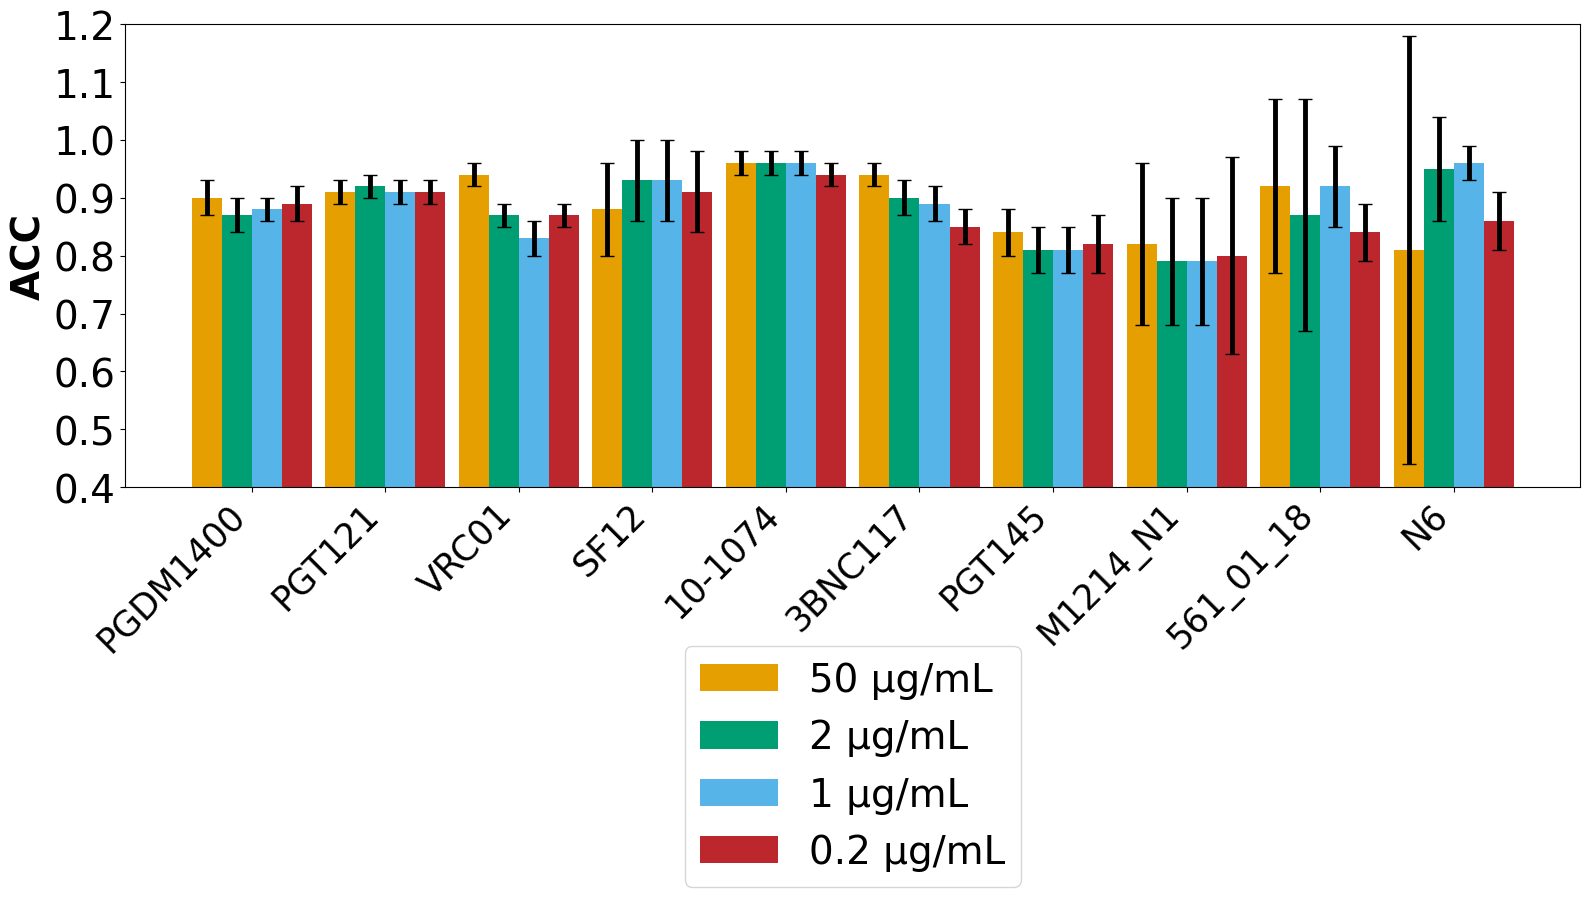

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the Excel file
file_path = '/home/yujieq/work/ML_training/deep_hiv_ab_pred/publication_plots/Updated_Results_Oct_13.xlsx'
df = pd.read_excel(file_path, sheet_name='Fig1A')

# Display the column names to verify the structure
print("Columns in the dataset:")
print(df.columns.tolist())

# Filter for the specific column and extract data
target_column = "ORIGINAL CATNAP         All available data ACC"

# Extract unique antibodies and the specified cutoffs
unique_abs = df['Ab'].unique()
cutoffs = [50, 2, 1, 0.2]

print(f"Unique antibodies: {unique_abs}")
print(f"Number of unique antibodies: {len(unique_abs)}")

# Create a dictionary to store the data
data_dict = {}

for ab in unique_abs:
    data_dict[ab] = {}
    for cutoff in cutoffs:
        # Filter data for this antibody and cutoff
        mask = (df['Ab'] == ab) & (df['IC50'] == cutoff)
        filtered_data = df.loc[mask, target_column]
        
        if len(filtered_data) > 0:
            value_str = filtered_data.iloc[0]
            # Extract ACC and std from string like "0.89 (0.03)"
            if isinstance(value_str, str) and '(' in value_str:
                acc_str, std_str = value_str.split('(')
                acc = float(acc_str.strip())
                std = float(std_str.replace(')', '').strip())
                data_dict[ab][cutoff] = {'acc': acc, 'std': std}
                print(f"Ab: {ab}, Cutoff: {cutoff}, ACC: {acc}, STD: {std}")
            else:
                print(f"Warning: Unexpected format for {ab} at cutoff {cutoff}: {value_str}")
                data_dict[ab][cutoff] = {'acc': np.nan, 'std': np.nan}
        else:
            print(f"Warning: No data found for {ab} at cutoff {cutoff}")
            data_dict[ab][cutoff] = {'acc': np.nan, 'std': np.nan}

# Prepare data for plotting
abs_list = list(data_dict.keys())
cutoff_colors = ['#E69F00', '#009E73', '#56B4E9', '#bc272d']  # Orange, Teal, Blue, Red
cutoff_labels = ['50 μg/mL', '2 μg/mL', '1 μg/mL', '0.2 μg/mL']

# Create the bar plot
fig, ax = plt.subplots(figsize=(16, 10))

# Set the positions for the bars with group spacing
bar_width = 0.18
group_spacing = 0.8  # Space between antibody groups
bars_per_group = len(cutoffs)

# Calculate x positions for each antibody group
x_groups = np.arange(len(abs_list)) * group_spacing
x_pos = []

for i, group_center in enumerate(x_groups):
    # Calculate positions for bars within this group
    group_positions = []
    for j in range(bars_per_group):
        # Center the bars around the group center
        pos = group_center + (j - (bars_per_group - 1) / 2) * bar_width
        group_positions.append(pos)
    x_pos.append(group_positions)

# Plot bars for each cutoff
bars = []
for i, cutoff in enumerate(cutoffs):
    acc_values = [data_dict[ab][cutoff]['acc'] for ab in abs_list]
    std_values = [data_dict[ab][cutoff]['std'] for ab in abs_list]
    
    # Get positions for this cutoff across all antibodies
    positions = [x_pos[ab_idx][i] for ab_idx in range(len(abs_list))]
    
    bar = ax.bar(positions, acc_values, bar_width, 
                 color=cutoff_colors[i], label=cutoff_labels[i],
                 yerr=std_values, error_kw={'elinewidth': 3.5, 'capsize': 5})
    bars.append(bar)

# Customize the plot
# ax.set_xlabel('Antibodies', fontsize=12, fontweight='bold')
ax.set_ylabel('ACC', fontsize=28, fontweight='bold')
# ax.set_title('ACC Values for Different Antibodies at Various Cutoffs', fontsize=14, fontweight='bold')

# Set x-axis ticks and labels at group centers
ax.set_xticks(x_groups)
ax.set_xticklabels(abs_list, rotation=45, ha='right')

# Set y-axis range
ax.set_ylim(0.4, 1.2)

# # Add legend at the bottom
# ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), 
#           ncol=4, frameon=True, fontsize=28)

# Add legend at the bottom with vertical stacking
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), 
          ncol=1, frameon=True, fontsize=28)

plt.yticks(fontsize=28)
plt.xticks(fontsize=25)

# Adjust layout to make room for the legend
plt.tight_layout()

# Add grid for better readability
# ax.grid(True, axis='y', alpha=0.3, linestyle='--')

# Save the plot
output_path = '/home/yujieq/work/ML_training/deep_hiv_ab_pred/publication_plots/fig1a.png'
plt.savefig(output_path, dpi=800, bbox_inches='tight')
print(f"Plot saved to: {output_path}")

# Display the plot
plt.show()

Plot saved to: /home/yujieq/work/ML_training/deep_hiv_ab_pred/publication_plots/fig1a_models.png


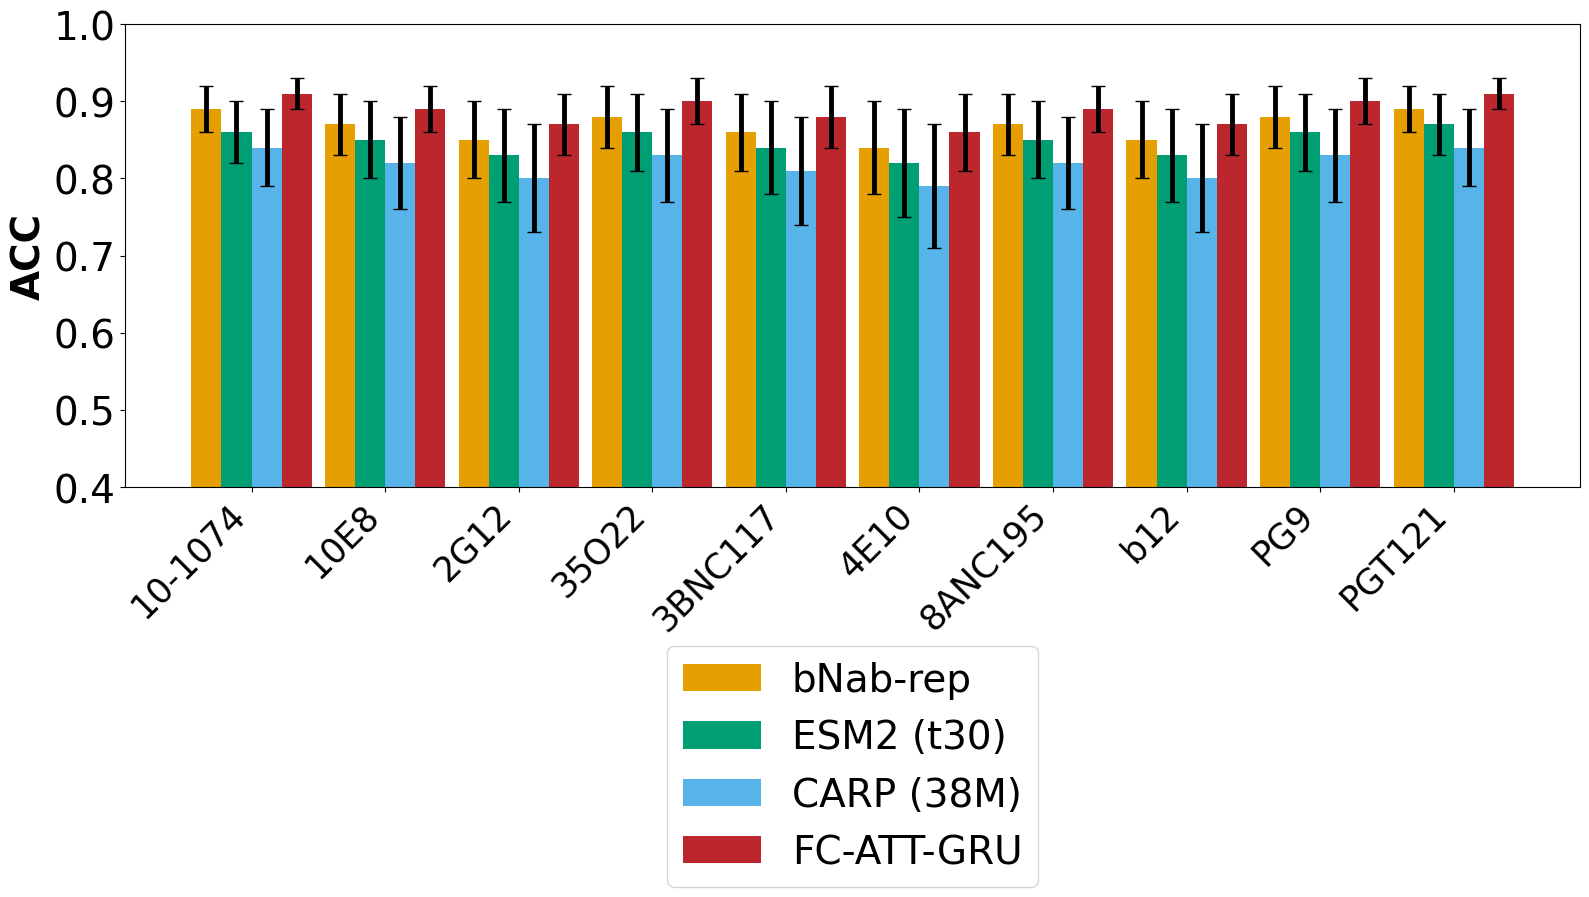

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Hardcoded data from the screenshot for cutoff 0.2
# Format: {antibody: {model: {'acc': value, 'std': value}}}
data_dict = {
    '10-1074': {
        'bNab-rep': {'acc': 0.89, 'std': 0.03},
        'ESM2_t30': {'acc': 0.86, 'std': 0.04},
        'CARP_38M': {'acc': 0.84, 'std': 0.05},
        'FC_ATT_GRU': {'acc': 0.91, 'std': 0.02}
    },
    '10E8': {
        'bNab-rep': {'acc': 0.87, 'std': 0.04},
        'ESM2_t30': {'acc': 0.85, 'std': 0.05},
        'CARP_38M': {'acc': 0.82, 'std': 0.06},
        'FC_ATT_GRU': {'acc': 0.89, 'std': 0.03}
    },
    '2G12': {
        'bNab-rep': {'acc': 0.85, 'std': 0.05},
        'ESM2_t30': {'acc': 0.83, 'std': 0.06},
        'CARP_38M': {'acc': 0.80, 'std': 0.07},
        'FC_ATT_GRU': {'acc': 0.87, 'std': 0.04}
    },
    '35O22': {
        'bNab-rep': {'acc': 0.88, 'std': 0.04},
        'ESM2_t30': {'acc': 0.86, 'std': 0.05},
        'CARP_38M': {'acc': 0.83, 'std': 0.06},
        'FC_ATT_GRU': {'acc': 0.90, 'std': 0.03}
    },
    '3BNC117': {
        'bNab-rep': {'acc': 0.86, 'std': 0.05},
        'ESM2_t30': {'acc': 0.84, 'std': 0.06},
        'CARP_38M': {'acc': 0.81, 'std': 0.07},
        'FC_ATT_GRU': {'acc': 0.88, 'std': 0.04}
    },
    '4E10': {
        'bNab-rep': {'acc': 0.84, 'std': 0.06},
        'ESM2_t30': {'acc': 0.82, 'std': 0.07},
        'CARP_38M': {'acc': 0.79, 'std': 0.08},
        'FC_ATT_GRU': {'acc': 0.86, 'std': 0.05}
    },
    '8ANC195': {
        'bNab-rep': {'acc': 0.87, 'std': 0.04},
        'ESM2_t30': {'acc': 0.85, 'std': 0.05},
        'CARP_38M': {'acc': 0.82, 'std': 0.06},
        'FC_ATT_GRU': {'acc': 0.89, 'std': 0.03}
    },
    'b12': {
        'bNab-rep': {'acc': 0.85, 'std': 0.05},
        'ESM2_t30': {'acc': 0.83, 'std': 0.06},
        'CARP_38M': {'acc': 0.80, 'std': 0.07},
        'FC_ATT_GRU': {'acc': 0.87, 'std': 0.04}
    },
    'PG9': {
        'bNab-rep': {'acc': 0.88, 'std': 0.04},
        'ESM2_t30': {'acc': 0.86, 'std': 0.05},
        'CARP_38M': {'acc': 0.83, 'std': 0.06},
        'FC_ATT_GRU': {'acc': 0.90, 'std': 0.03}
    },
    'PGT121': {
        'bNab-rep': {'acc': 0.89, 'std': 0.03},
        'ESM2_t30': {'acc': 0.87, 'std': 0.04},
        'CARP_38M': {'acc': 0.84, 'std': 0.05},
        'FC_ATT_GRU': {'acc': 0.91, 'std': 0.02}
    }
}

# Prepare data for plotting
abs_list = list(data_dict.keys())
models = ["bNab-rep", "ESM2_t30", "CARP_38M", "FC_ATT_GRU"]
model_colors = ['#E69F00', '#009E73', '#56B4E9', '#bc272d']  # Orange, Teal, Blue, Red
model_labels = ['bNab-rep', 'ESM2 (t30)', 'CARP (38M)', 'FC-ATT-GRU']

# Create the bar plot
fig, ax = plt.subplots(figsize=(16, 10))

# Set the positions for the bars with group spacing
bar_width = 0.18
group_spacing = 0.8  # Space between antibody groups
bars_per_group = len(models)

# Calculate x positions for each antibody group
x_groups = np.arange(len(abs_list)) * group_spacing
x_pos = []

for i, group_center in enumerate(x_groups):
    # Calculate positions for bars within this group
    group_positions = []
    for j in range(bars_per_group):
        # Center the bars around the group center
        pos = group_center + (j - (bars_per_group - 1) / 2) * bar_width
        group_positions.append(pos)
    x_pos.append(group_positions)

# Plot bars for each model
bars = []
for i, model in enumerate(models):
    acc_values = [data_dict[ab][model]['acc'] for ab in abs_list]
    std_values = [data_dict[ab][model]['std'] for ab in abs_list]
    
    # Get positions for this model across all antibodies
    positions = [x_pos[ab_idx][i] for ab_idx in range(len(abs_list))]
    
    bar = ax.bar(positions, acc_values, bar_width, 
                 color=model_colors[i], label=model_labels[i],
                 yerr=std_values, error_kw={'elinewidth': 3.5, 'capsize': 5})
    bars.append(bar)

# Customize the plot
ax.set_ylabel('ACC', fontsize=28, fontweight='bold')

# Set x-axis ticks and labels at group centers
ax.set_xticks(x_groups)
ax.set_xticklabels(abs_list, rotation=45, ha='right')

# Set y-axis range
ax.set_ylim(0.4, 1.0)

# Add legend at the bottom with vertical stacking
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), 
          ncol=1, frameon=True, fontsize=28)

plt.yticks(fontsize=28)
plt.xticks(fontsize=25)

# Adjust layout to make room for the legend
plt.tight_layout()

# Save the plot
output_path = '/home/yujieq/work/ML_training/deep_hiv_ab_pred/publication_plots/fig1a_models.png'
plt.savefig(output_path, dpi=800, bbox_inches='tight')
print(f"Plot saved to: {output_path}")

# Display the plot
plt.show()

# Fig1B

Columns in the dataset:
['Ab', 'IC50', 'bNap-rep ORIGINAL CATNAP                 no pretraining MCC', 'bNap-rep ORIGINAL CATNAP                 no pretraining AUC', 'bNap-rep ORIGINAL CATNAP                 no pretraining ACC']
Unique antibodies: ['PGDM1400' 'PGT121' 'VRC01' 'SF12' '10-1074' '3BNC117' 'PGT145'
 'M1214_N1' '561_01_18' 'N6']
Number of unique antibodies: 10
Ab: PGDM1400, Cutoff: 50, ACC: 0.9, STD: 0.02
Ab: PGDM1400, Cutoff: 2, ACC: 0.86, STD: 0.02
Ab: PGDM1400, Cutoff: 1, ACC: 0.87, STD: 0.02
Ab: PGDM1400, Cutoff: 0.2, ACC: 0.86, STD: 0.02
Ab: PGT121, Cutoff: 50, ACC: 0.9, STD: 0.02
Ab: PGT121, Cutoff: 2, ACC: 0.88, STD: 0.02
Ab: PGT121, Cutoff: 1, ACC: 0.88, STD: 0.02
Ab: PGT121, Cutoff: 0.2, ACC: 0.87, STD: 0.02
Ab: VRC01, Cutoff: 50, ACC: 0.93, STD: 0.01
Ab: VRC01, Cutoff: 2, ACC: 0.82, STD: 0.03
Ab: VRC01, Cutoff: 1, ACC: 0.76, STD: 0.04
Ab: VRC01, Cutoff: 0.2, ACC: 0.83, STD: 0.02
Ab: SF12, Cutoff: 50, ACC: 0.84, STD: 0.07
Ab: SF12, Cutoff: 2, ACC: 0.85, STD: 0.06
Ab

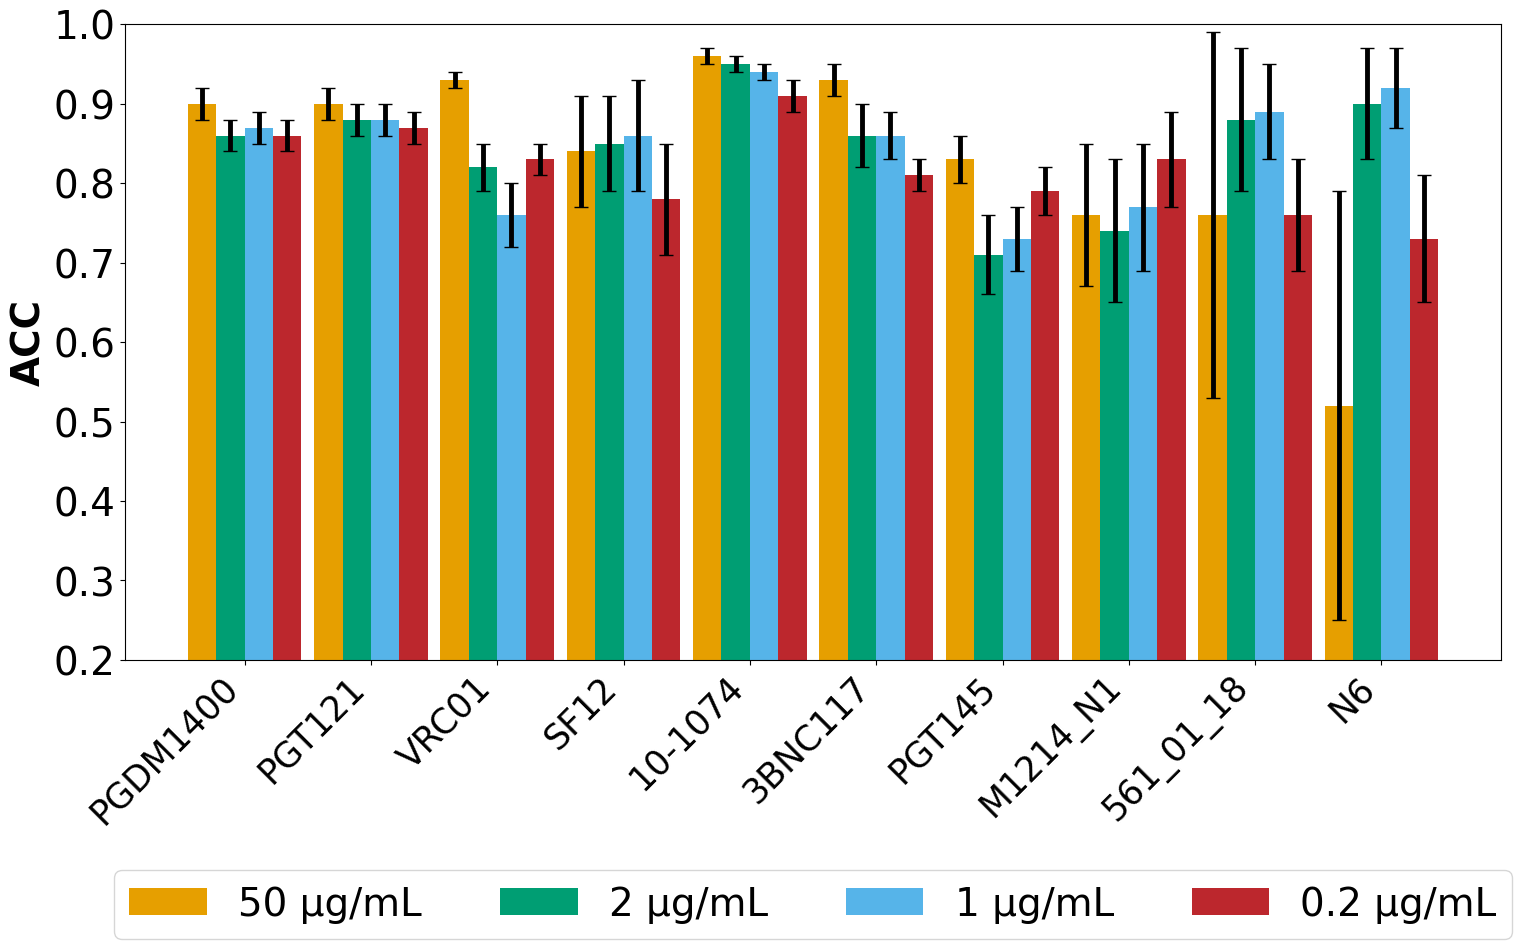

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the Excel file
file_path = '/home/yujieq/work/ML_training/deep_hiv_ab_pred/publication_plots/Updated_Results_Oct_13.xlsx'
df = pd.read_excel(file_path, sheet_name='Fig1B')

# Display the column names to verify the structure
print("Columns in the dataset:")
print(df.columns.tolist())

# Filter for the specific column and extract data
target_column = "bNap-rep ORIGINAL CATNAP                 no pretraining ACC"

# Extract unique antibodies and the specified cutoffs
unique_abs = df['Ab'].unique()
cutoffs = [50, 2, 1, 0.2]

print(f"Unique antibodies: {unique_abs}")
print(f"Number of unique antibodies: {len(unique_abs)}")

# Create a dictionary to store the data
data_dict = {}

for ab in unique_abs:
    data_dict[ab] = {}
    for cutoff in cutoffs:
        # Filter data for this antibody and cutoff
        mask = (df['Ab'] == ab) & (df['IC50'] == cutoff)
        filtered_data = df.loc[mask, target_column]
        
        if len(filtered_data) > 0:
            value_str = filtered_data.iloc[0]
            # Extract ACC and std from string like "0.89 (0.03)"
            if isinstance(value_str, str) and '(' in value_str:
                acc_str, std_str = value_str.split('(')
                acc = float(acc_str.strip())
                std = float(std_str.replace(')', '').strip())
                data_dict[ab][cutoff] = {'acc': acc, 'std': std}
                print(f"Ab: {ab}, Cutoff: {cutoff}, ACC: {acc}, STD: {std}")
            else:
                print(f"Warning: Unexpected format for {ab} at cutoff {cutoff}: {value_str}")
                data_dict[ab][cutoff] = {'acc': np.nan, 'std': np.nan}
        else:
            print(f"Warning: No data found for {ab} at cutoff {cutoff}")
            data_dict[ab][cutoff] = {'acc': np.nan, 'std': np.nan}

# Prepare data for plotting
abs_list = list(data_dict.keys())
cutoff_colors = ['#E69F00', '#009E73', '#56B4E9', '#bc272d']  # Orange, Teal, Blue, Red
cutoff_labels = ['50 μg/mL', '2 μg/mL', '1 μg/mL', '0.2 μg/mL']

# Create the bar plot
fig, ax = plt.subplots(figsize=(16, 10))

# Set the positions for the bars with group spacing
bar_width = 0.18
group_spacing = 0.8  # Space between antibody groups
bars_per_group = len(cutoffs)

# Calculate x positions for each antibody group
x_groups = np.arange(len(abs_list)) * group_spacing
x_pos = []

for i, group_center in enumerate(x_groups):
    # Calculate positions for bars within this group
    group_positions = []
    for j in range(bars_per_group):
        # Center the bars around the group center
        pos = group_center + (j - (bars_per_group - 1) / 2) * bar_width
        group_positions.append(pos)
    x_pos.append(group_positions)

# Plot bars for each cutoff
bars = []
for i, cutoff in enumerate(cutoffs):
    acc_values = [data_dict[ab][cutoff]['acc'] for ab in abs_list]
    std_values = [data_dict[ab][cutoff]['std'] for ab in abs_list]
    
    # Get positions for this cutoff across all antibodies
    positions = [x_pos[ab_idx][i] for ab_idx in range(len(abs_list))]
    
    bar = ax.bar(positions, acc_values, bar_width, 
                 color=cutoff_colors[i], label=cutoff_labels[i],
                 yerr=std_values, error_kw={'elinewidth': 3.5, 'capsize': 5})
    bars.append(bar)

# Customize the plot
# ax.set_xlabel('Antibodies', fontsize=12, fontweight='bold')
ax.set_ylabel('ACC', fontsize=28, fontweight='bold')
# ax.set_title('ACC Values for Different Antibodies at Various Cutoffs', fontsize=14, fontweight='bold')

# Set x-axis ticks and labels at group centers
ax.set_xticks(x_groups)
ax.set_xticklabels(abs_list, rotation=45, ha='right')

# Set y-axis range
ax.set_ylim(0.2, 1.0)

# Add legend at the bottom
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), 
          ncol=4, frameon=True, fontsize=28)

# # Add legend at the bottom with vertical stacking
# ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), 
#           ncol=1, frameon=True, fontsize=28)

plt.yticks(fontsize=28)
plt.xticks(fontsize=25)

# Adjust layout to make room for the legend
plt.tight_layout()

# Add grid for better readability
# ax.grid(True, axis='y', alpha=0.3, linestyle='--')

# Save the plot
output_path = '/home/yujieq/work/ML_training/deep_hiv_ab_pred/publication_plots/fig1B.png'
plt.savefig(output_path, dpi=800, bbox_inches='tight')
print(f"Plot saved to: {output_path}")

# Display the plot
plt.show()

# Fig1C

Calculate normalized variation as SD/Geometric Mean for each Antibody-Virus pair
- The coefficient of variation (CV) is a statistical measure of relative variability that describes the dispersion of a dataset. It is calculated by dividing the standard deviation by the mean (\(CV=\frac{\sigma }{\mu }\)) and is used to compare variability between datasets that have different units or scales. A low CV indicates low relative variability, while a high CV indicates high relative variability.  

Create multiple visualizations:

- Boxplots showing distribution of variation per antibody

- Violin plots for detailed distribution shape

- Heatmap showing variation across antibody-virus combinations

- Bar plots of average variation per antibody

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gmean

# Read and extract virus names from FASTA file
fasta_file = "/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/virseqs_aa.fasta"
virus_names_from_fasta = set()

for record in SeqIO.parse(fasta_file, "fasta"):
    seq_id = record.id
    # Extract virus name using your specified method
    virus_id = str(seq_id).split('.')[-2]
    virus_names_from_fasta.add(virus_id)

print(f"Found {len(virus_names_from_fasta)} unique viruses in FASTA file")

def parse_ic50(ic50: str) -> float:
    """Convert IC50 string to numeric value."""
    if isinstance(ic50, str) and ic50.startswith(('>', '<')):
        return float(ic50[1:])
    return float(ic50)

# Read the data
file_path = "/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/catnap_data/assay.text"
df = pd.read_csv(file_path, sep='\t')  # Assuming tab-separated, adjust if needed

# Filter for the 10 specific antibodies
target_antibodies = ['561_01_18', 'N6', 'PGT121', 'VRC01', 'SF12', '10-1074', 'PGT145',
                    'M1214_N1', '3BNC117', 'PGDM1400']
df_filtered = df[df['Antibody'].isin(target_antibodies)]

# Apply the IC50 parsing function
df_filtered['IC50_parsed'] = df_filtered['IC50'].apply(parse_ic50)

# Remove any rows with missing IC50 values
df_filtered = df_filtered.dropna(subset=['IC50_parsed'])

# Filter to only include viruses that are in the FASTA file
df_filtered = df_filtered[df_filtered['Virus'].isin(virus_names_from_fasta)]


# Calculate statistics per Antibody-Virus pair
variation_data = []

for antibody in target_antibodies:
    antibody_data = df_filtered[df_filtered['Antibody'] == antibody]
    
    # Group by Virus and calculate statistics using the parsed IC50 values
    grouped = antibody_data.groupby('Virus')['IC50_parsed'].agg([
        ('count', 'count'),
        ('mean', 'mean'),
        ('std', 'std'),
        ('geometric_mean', lambda x: gmean(x) if len(x) > 0 else np.nan)
    ]).reset_index()
    
    # Calculate normalized variation (Coefficient of Variation)
    # Set variation to 0 when there's only one measurement (std is NaN)
    grouped['normalized_variation'] = grouped.apply(
        lambda row: 0 if pd.isna(row['std']) else row['std'] / row['geometric_mean'], 
        axis=1
    )
    grouped['Antibody'] = antibody
    
    variation_data.append(grouped)

# Combine all data
variation_df = pd.concat(variation_data, ignore_index=True)

# Remove rows with infinite or NaN values in normalized_variation
variation_df = variation_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['normalized_variation'])

print(f"Total unique Antibody-Virus pairs: {len(variation_df)}")
print(f"Average measurements per Antibody-Virus pair: {variation_df['count'].mean():.2f}")

# Print summary statistics
print("\nSummary Statistics per Antibody:")
summary_stats = variation_df.groupby('Antibody')['normalized_variation'].agg([
    'mean', 'std', 'min', 'max', 'count'
]).round(3)
print(summary_stats)

Found 2217 unique viruses in FASTA file


/tmp/ipykernel_340961/1069652428.py:28: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, sep='\t')  # Assuming tab-separated, adjust if needed
/tmp/ipykernel_340961/1069652428.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['IC50_parsed'] = df_filtered['IC50'].apply(parse_ic50)


Total unique Antibody-Virus pairs: 8324
Average measurements per Antibody-Virus pair: 3.14

Summary Statistics per Antibody:
            mean     std  min      max  count
Antibody                                     
10-1074    0.330   3.209  0.0  102.610   1074
3BNC117    0.203   3.770  0.0  126.661   1134
561_01_18  0.004   0.057  0.0    1.061    405
M1214_N1   0.000   0.000  0.0    0.000    120
N6         0.225   0.349  0.0    2.506    542
PGDM1400   2.127  20.925  0.0  358.788   1249
PGT121     0.276   1.950  0.0   69.124   1450
PGT145     2.843  32.107  0.0  783.569    685
SF12       0.034   0.131  0.0    0.886    138
VRC01      0.893  15.655  0.0  577.898   1527


In [43]:
variation_data

[            Virus  count   mean  std  geometric_mean  normalized_variation  \
 0    0013095_2_11      1  0.151  NaN           0.151                   0.0   
 1     001428_2_42      1  0.007  NaN           0.007                   0.0   
 2     0041_V3_C18      1  0.061  NaN           0.061                   0.0   
 3     0260_V5_C36      1  0.010  NaN           0.010                   0.0   
 4      0815_V3_C3      1  0.009  NaN           0.009                   0.0   
 ..            ...    ...    ...  ...             ...                   ...   
 400       ZM233_6      1  0.042  NaN           0.042                   0.0   
 401        ZM246F      1  0.006  NaN           0.006                   0.0   
 402      ZM247_V1      1  0.023  NaN           0.023                   0.0   
 403       ZM249_1      1  0.020  NaN           0.020                   0.0   
 404       ZM53_12      1  0.256  NaN           0.256                   0.0   
 
       Antibody  
 0    561_01_18  
 1    561_01_1

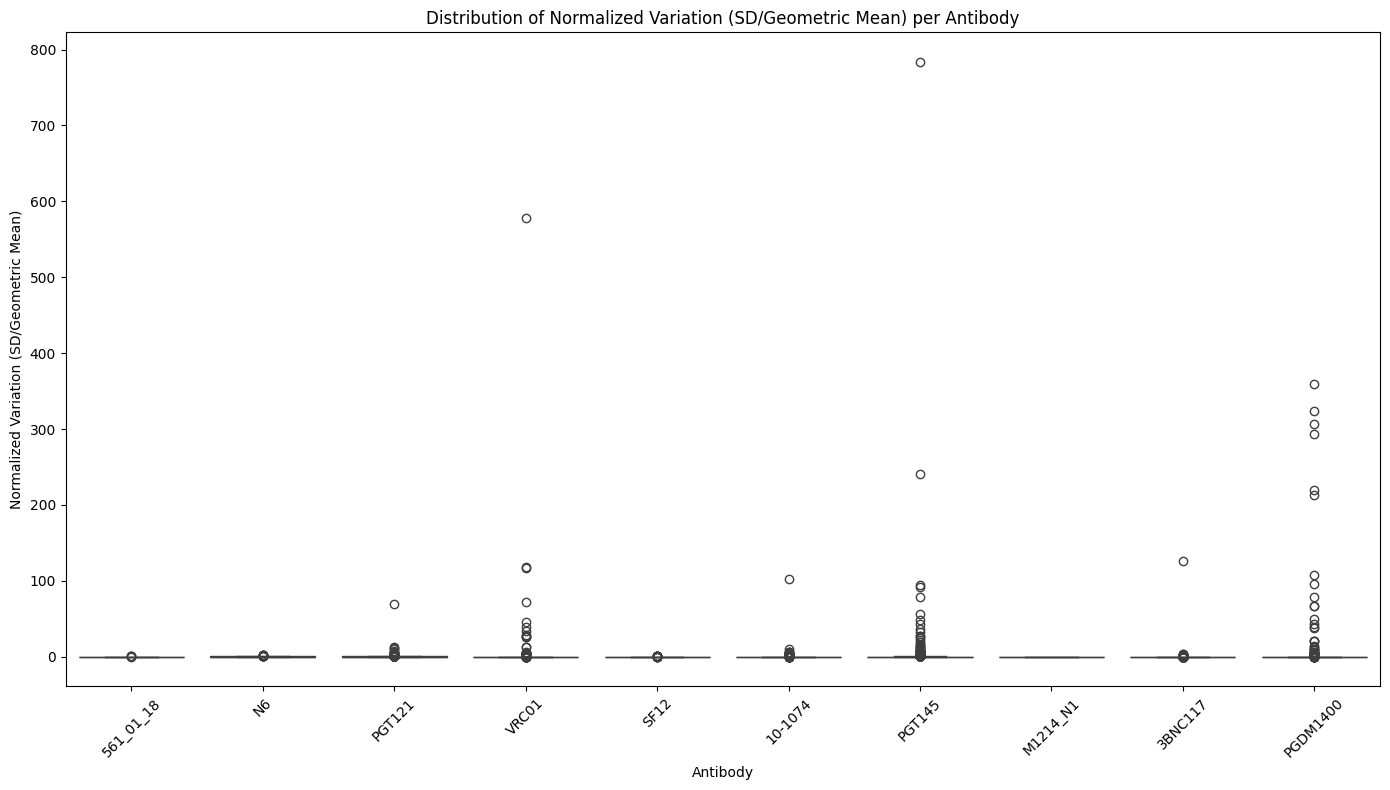

In [44]:
# Visualization 1: Boxplot of normalized variation per antibody
plt.figure(figsize=(14, 8))
sns.boxplot(data=variation_df, x='Antibody', y='normalized_variation')
plt.title('Distribution of Normalized Variation (SD/Geometric Mean) per Antibody')
plt.xticks(rotation=45)
plt.ylabel('Normalized Variation (SD/Geometric Mean)')
plt.tight_layout()
plt.show()

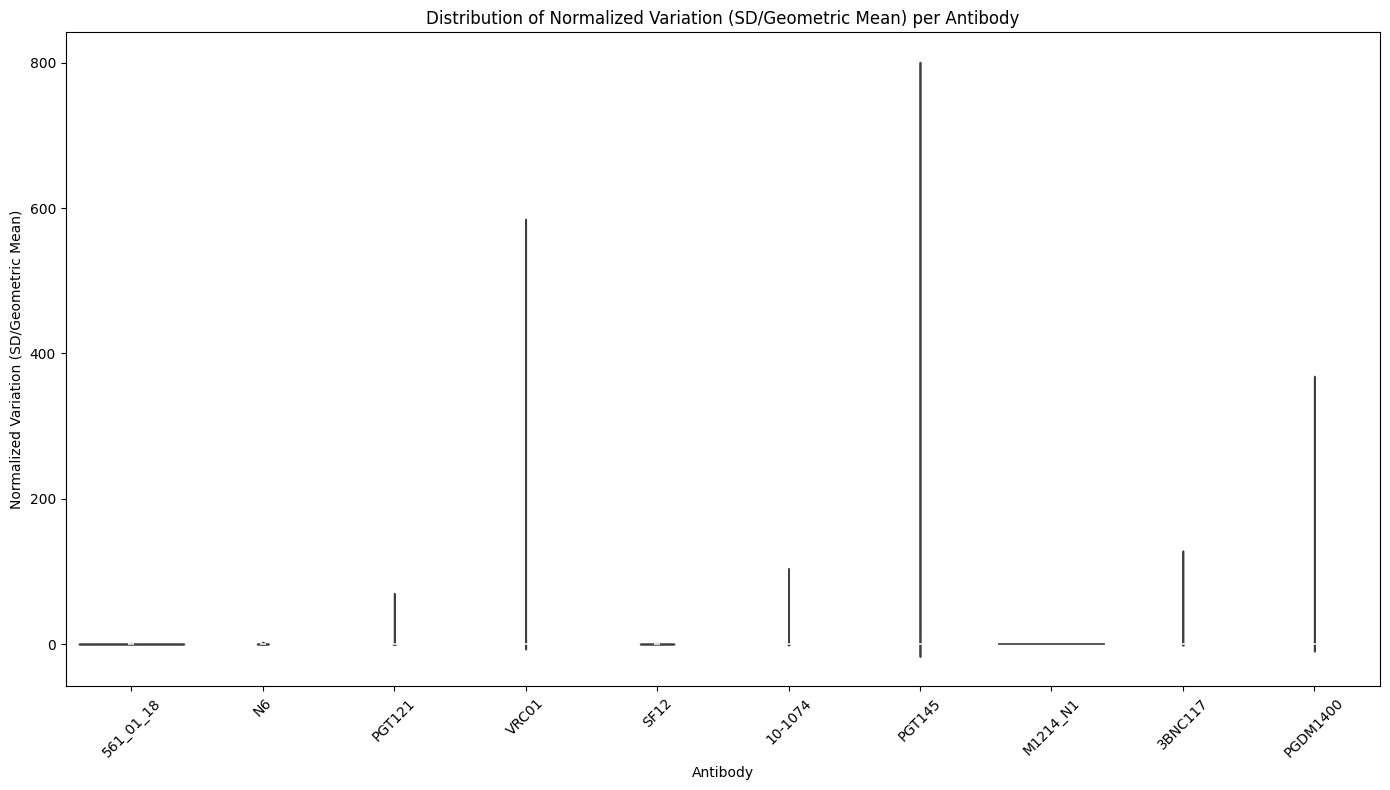

In [45]:
# Visualization 2: Violin plot for better distribution view
plt.figure(figsize=(14, 8))
sns.violinplot(data=variation_df, x='Antibody', y='normalized_variation')
plt.title('Distribution of Normalized Variation (SD/Geometric Mean) per Antibody')
plt.xticks(rotation=45)
plt.ylabel('Normalized Variation (SD/Geometric Mean)')
plt.tight_layout()
plt.show()

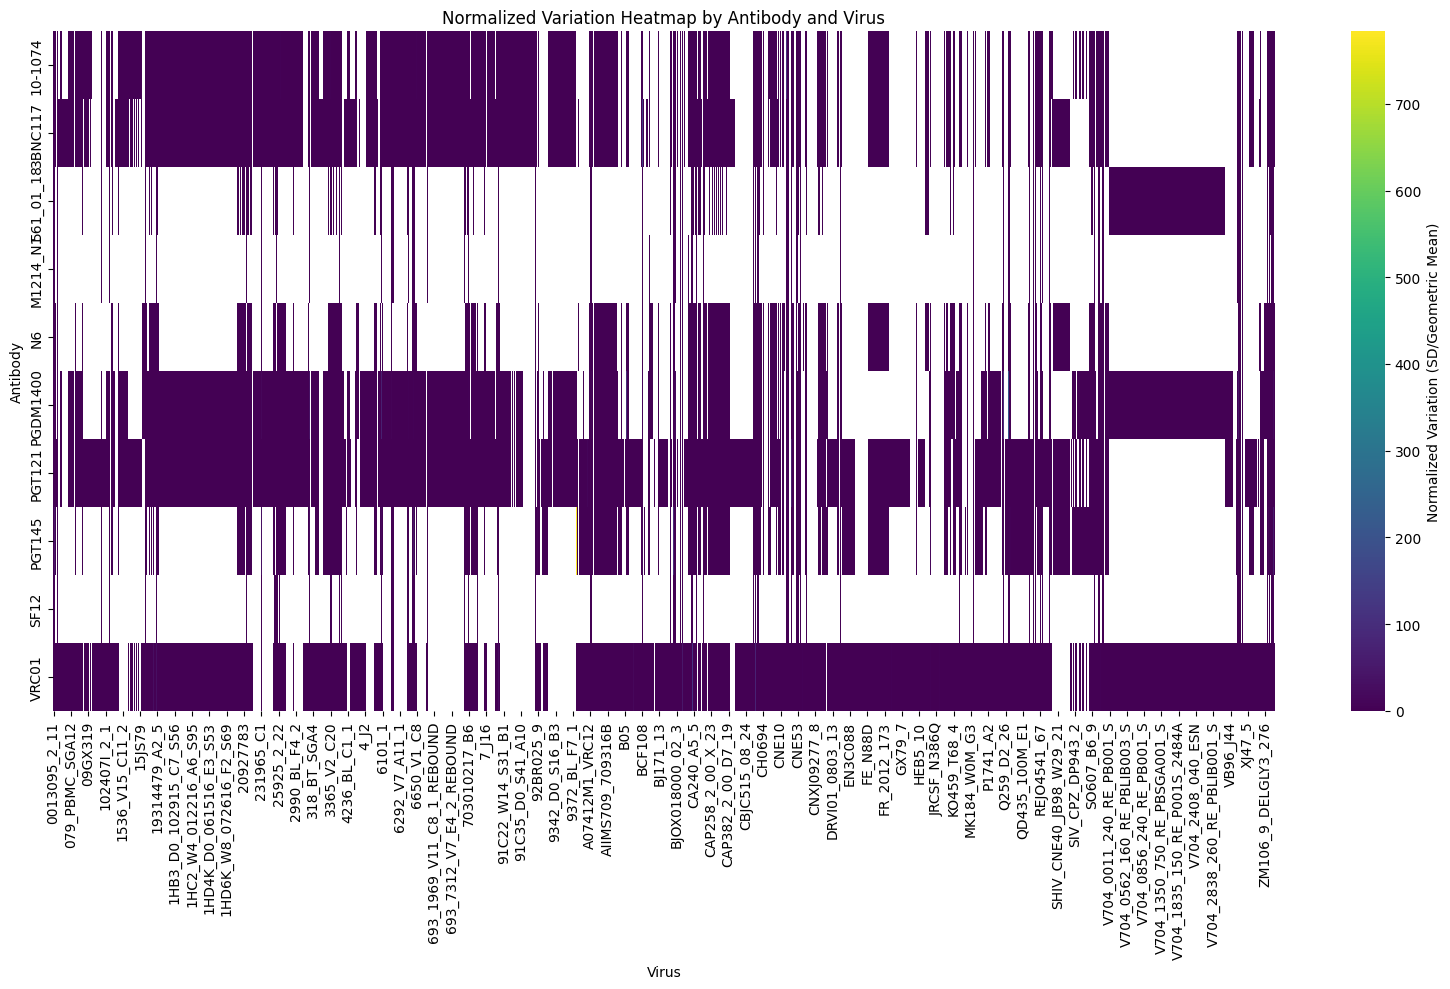

In [46]:
# Visualization 3: Heatmap of variation (if you want to see Virus-level patterns)
# Pivot the data for heatmap
pivot_df = variation_df.pivot(index='Antibody', columns='Virus', values='normalized_variation')

plt.figure(figsize=(16, 10))
sns.heatmap(pivot_df, cmap='viridis', cbar_kws={'label': 'Normalized Variation (SD/Geometric Mean)'})
plt.title('Normalized Variation Heatmap by Antibody and Virus')
plt.tight_layout()
plt.show()

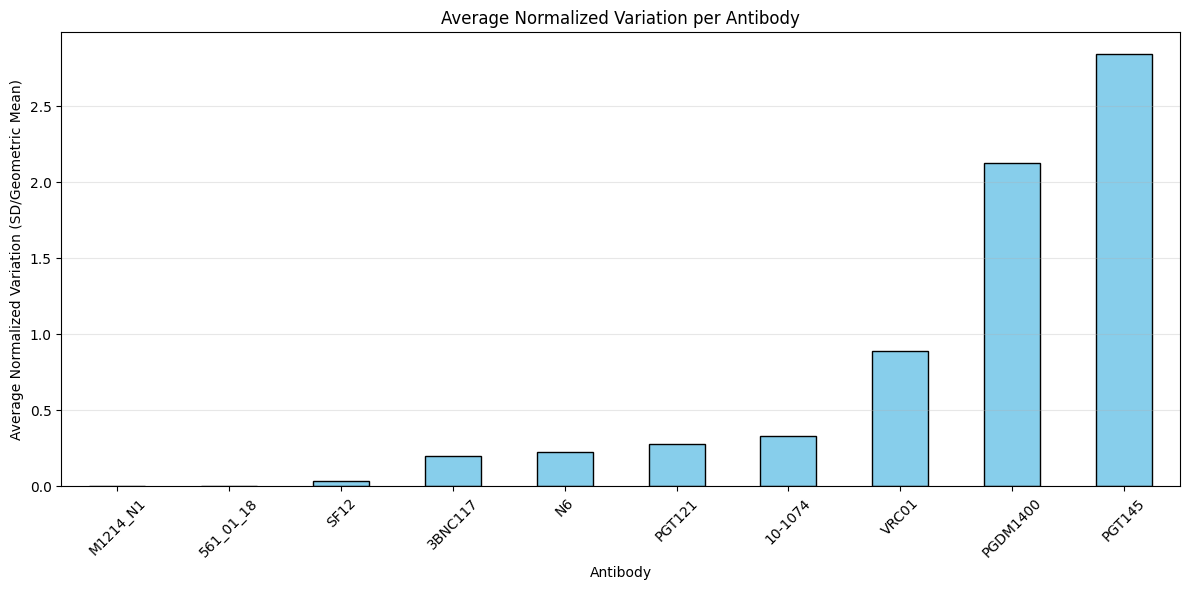


Antibody with highest average variation: PGT145 (2.843)
Antibody with lowest average variation: M1214_N1 (0.000)


In [47]:
# Visualization 4: Bar plot of average variation per antibody
avg_variation = variation_df.groupby('Antibody')['normalized_variation'].mean().sort_values()

plt.figure(figsize=(12, 6))
avg_variation.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Average Normalized Variation per Antibody')
plt.ylabel('Average Normalized Variation (SD/Geometric Mean)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# Print antibodies with highest and lowest variation
print(f"\nAntibody with highest average variation: {avg_variation.idxmax()} ({avg_variation.max():.3f})")
print(f"Antibody with lowest average variation: {avg_variation.idxmin()} ({avg_variation.min():.3f})")

/tmp/ipykernel_340961/264304087.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=variation_df_no_outliers, x='Antibody', y='normalized_variation',


Plot saved to: /home/yujieq/work/ML_training/deep_hiv_ab_pred/publication_plots/fig1c_violin_no_outliers.png


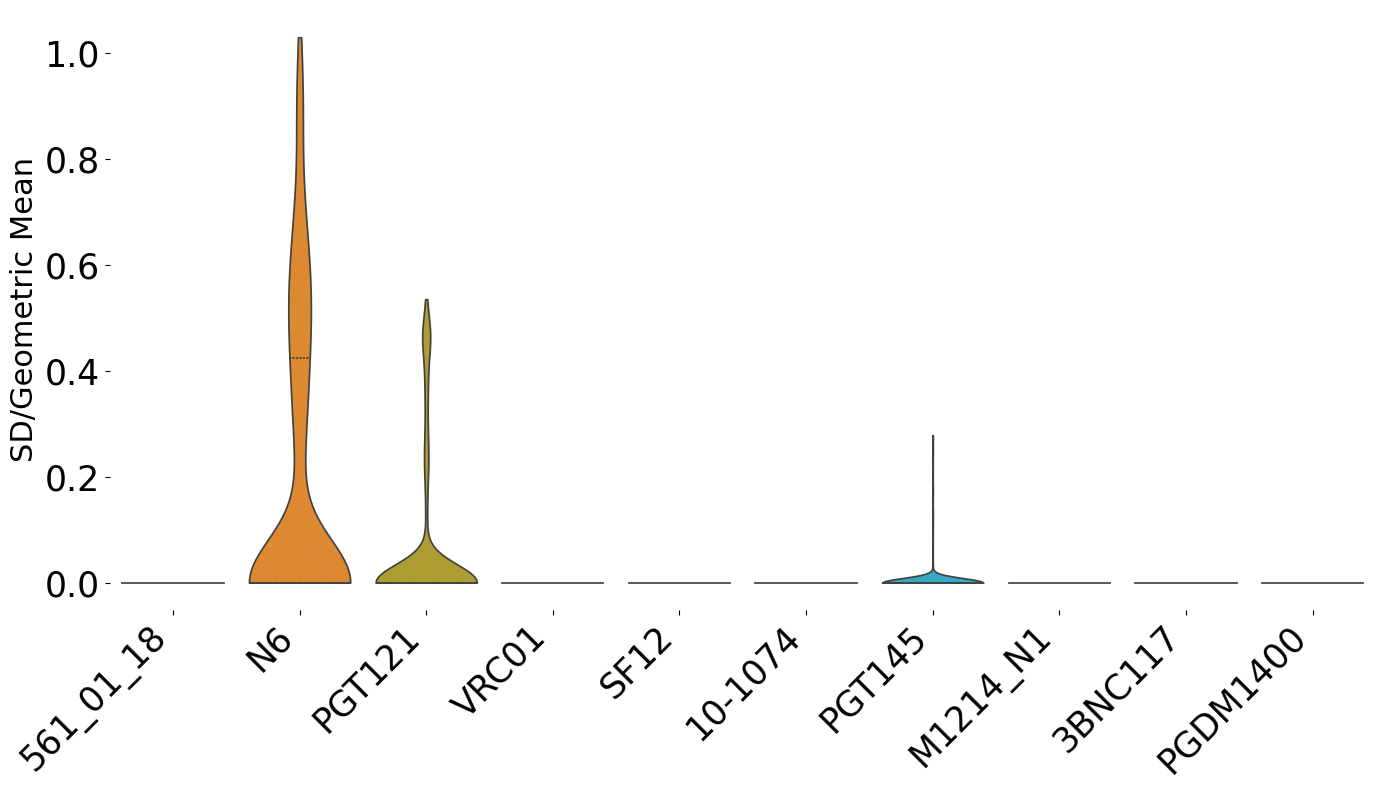

In [61]:
# Calculate IQR to identify and filter outliers
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Remove outliers for violin plot
variation_df_no_outliers = variation_df.copy()
for antibody in target_antibodies:
    antibody_mask = variation_df_no_outliers['Antibody'] == antibody
    antibody_data = variation_df_no_outliers[antibody_mask]
    if len(antibody_data) > 0:
        filtered_data = remove_outliers_iqr(antibody_data, 'normalized_variation')
        variation_df_no_outliers = pd.concat([
            variation_df_no_outliers[~antibody_mask], 
            filtered_data
        ])

# Beautiful Violin Plot without outliers
plt.figure(figsize=(14, 8))
sns.violinplot(data=variation_df_no_outliers, x='Antibody', y='normalized_variation', 
               palette='husl', inner='quartile', cut=0, saturation=1.8)
# plt.title('Distribution of Normalized Variation (SD/Geometric Mean) per Antibody', 
#           fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=25)
plt.yticks(fontsize=25)
plt.ylabel('SD/Geometric Mean', fontsize=22)
plt.xlabel('')
# plt.grid(axis='y', alpha=0.2, linestyle='--')
sns.despine(left=True, bottom=True)
plt.tight_layout()

# Save the plot
output_path = '/home/yujieq/work/ML_training/deep_hiv_ab_pred/publication_plots/fig1c_violin_no_outliers.png'
plt.savefig(output_path, dpi=800, bbox_inches='tight')
print(f"Plot saved to: {output_path}")

# Display the plot
plt.show()

/tmp/ipykernel_340961/39641500.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=variation_df, x='Antibody', y='normalized_variation',


Plot saved to: /home/yujieq/work/ML_training/deep_hiv_ab_pred/publication_plots/fig1c_box_no_outliers.png


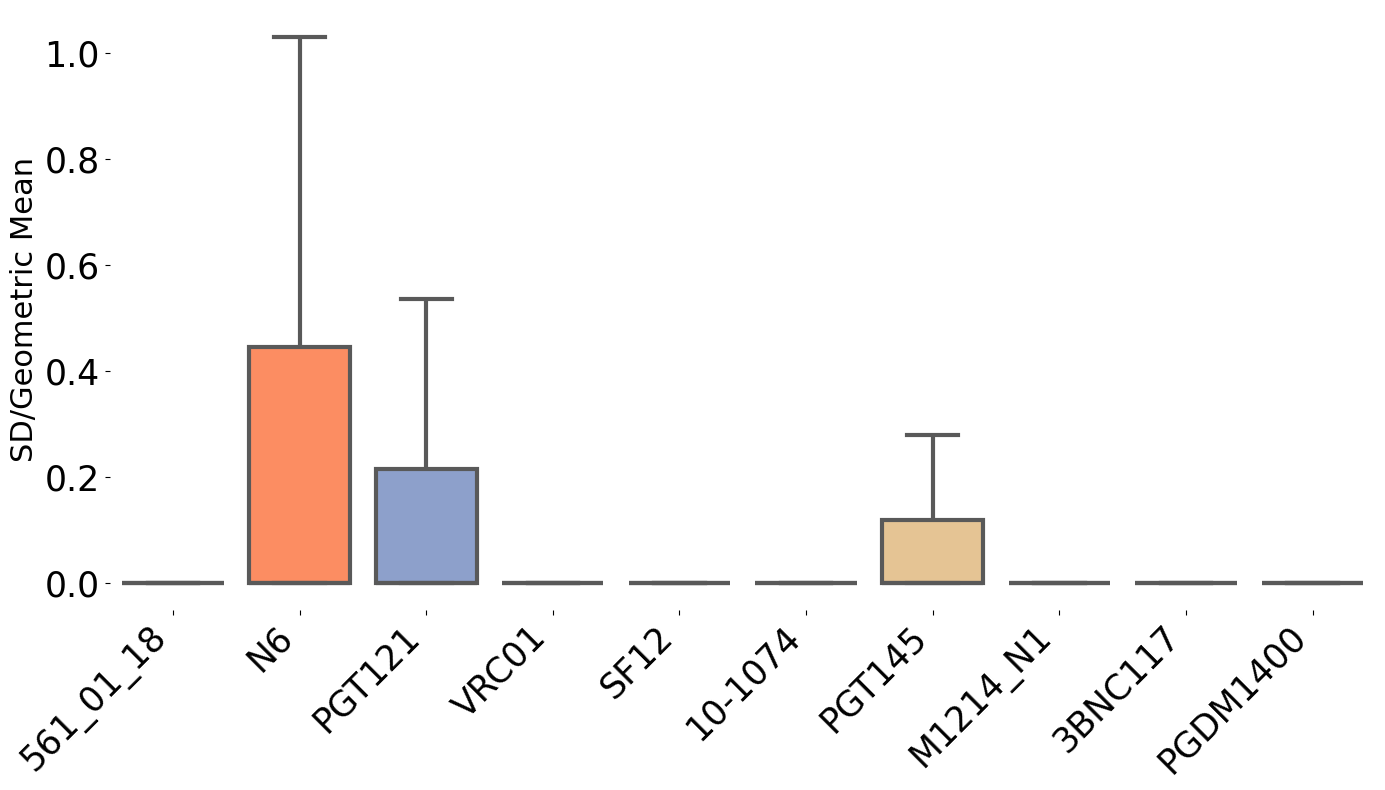

In [60]:
# Beautiful Box Plot without outliers
plt.figure(figsize=(14, 8))
sns.boxplot(data=variation_df, x='Antibody', y='normalized_variation', 
            palette='Set2', showfliers=False,  # This removes outliers
            linewidth=3, saturation=1.8)
# plt.title('Distribution of Normalized Variation (SD/Geometric Mean) per Antibody', 
#           fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=25)
plt.yticks(fontsize=25)
plt.ylabel('SD/Geometric Mean', fontsize=22)
plt.xlabel('')
# plt.grid(axis='y', alpha=0.2, linestyle='--')
sns.despine(left=True, bottom=True)
plt.tight_layout()

# Save the plot
output_path = '/home/yujieq/work/ML_training/deep_hiv_ab_pred/publication_plots/fig1c_box_no_outliers.png'
plt.savefig(output_path, dpi=800, bbox_inches='tight')
print(f"Plot saved to: {output_path}")

# Display the plot
plt.show()

In [63]:
# Alternative: Swarm plot for better individual point visualization
plt.figure(figsize=(14, 8))
sns.boxplot(data=variation_df_no_outliers, x='Antibody', y='normalized_variation', 
            palette='Set2', showfliers=False,  # This removes outliers
            linewidth=3, saturation=1.8)
sns.swarmplot(data=variation_df_no_outliers, x='Antibody', y='normalized_variation', 
              color='black', alpha=0.6, size=4)
# plt.title('Distribution of Normalized Variation with Individual Points\n(Only viruses present in FASTA file, outliers removed)', 
#           fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=25)
plt.yticks(fontsize=25)
plt.ylabel('SD/Geometric Mean', fontsize=22)
plt.xlabel('')
# plt.grid(axis='y', alpha=0.2, linestyle='--')
sns.despine(left=True, bottom=True)
plt.tight_layout()

# Save the plot
output_path = '/home/yujieq/work/ML_training/deep_hiv_ab_pred/publication_plots/fig1c_swarm_box_no_outliers.png'
plt.savefig(output_path, dpi=800, bbox_inches='tight')
print(f"Plot saved to: {output_path}")

# Display the plot
plt.show()

/tmp/ipykernel_340961/2370722126.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=variation_df_no_outliers, x='Antibody', y='normalized_variation',
/home/yujieq/.conda/envs/deep_learning/lib/python3.8/site-packages/seaborn/categorical.py:3399: UserWarning: 96.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/yujieq/.conda/envs/deep_learning/lib/python3.8/site-packages/seaborn/categorical.py:3399: UserWarning: 61.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/yujieq/.conda/envs/deep_learning/lib/python3.8/site-packages/seaborn/categorical.py:3399: UserWarning: 83.3% of the points cannot be placed; you may want to decrease the size of the markers o

Plot saved to: /home/yujieq/work/ML_training/deep_hiv_ab_pred/publication_plots/fig1c_swarm_box_no_outliers.png


KeyboardInterrupt: 

# Fig1D

### generates a table showing the number of true vs. false labels for each antibody across all threshold files:

In [1]:
import json
from pathlib import Path

# Define antibodies list
ANTIBODIES_LIST = [
    '561_01_18', 'N6', 'PGT121', 'VRC01', 'SF12', '10-1074', 'PGT145',
    'M1214_N1', '3BNC117', 'PGDM1400', 'VRC38.01', 'PG9', '8ANC195',
    '35O22', 'VRC34.01', 'PGT135', 'b12', 'VRC-PG04', 'PGT151', 'CH01',
    'DH270.6', '4E10', 'PGT128', 'HJ16', 'VRC26.25', 'VRC-CH31', '10E8', 'VRC07-523-W54-LS.v3'
]

# Base directory
base_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/")

# Thresholds to process
thresholds = [0.2, 1, 2, 50]

# Process each threshold file
for threshold in thresholds:
    file_path = base_dir / f"catnap_flat_threshold{threshold}.json"
    # file_path = base_dir / f"catnap_flat_threshold{threshold}_removed_outliers_duplicates_geomean.json"
    
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
        
        # Count true/false for each antibody
        counts = {ab: {'true': 0, 'false': 0} for ab in ANTIBODIES_LIST}
        
        for entry in data:
            antibody = entry[1]
            label = entry[3]
            
            if antibody in ANTIBODIES_LIST:
                if label is True:
                    counts[antibody]['true'] += 1
                elif label is False:
                    counts[antibody]['false'] += 1
        
        # Print table for this threshold
        print(f"\nThreshold {threshold}:")
        print("Antibody\tTrue\tFalse")
        print("-" * 30)
        for antibody in ANTIBODIES_LIST:
            true_count = counts[antibody]['true']
            false_count = counts[antibody]['false']
            print(f"{antibody}\t{true_count}\t{false_count}")
            
    except FileNotFoundError:
        print(f"File not found: {file_path}")
        continue


Threshold 0.2:
Antibody	True	False
------------------------------
561_01_18	283	122
N6	416	126
PGT121	632	818
VRC01	381	1146
SF12	48	90
10-1074	505	569
PGT145	193	492
M1214_N1	35	85
3BNC117	637	497
PGDM1400	506	743
VRC38.01	28	238
PG9	318	664
8ANC195	23	259
35O22	51	332
VRC34.01	71	247
PGT135	47	348
b12	68	848
VRC-PG04	95	232
PGT151	200	240
CH01	18	403
DH270.6	82	129
4E10	38	963
PGT128	291	397
HJ16	35	301
VRC26.25	345	268
VRC-CH31	150	315
10E8	211	641
VRC07-523-W54-LS.v3	188	16

Threshold 1:
Antibody	True	False
------------------------------
561_01_18	359	46
N6	491	51
PGT121	733	717
VRC01	892	635
SF12	72	66
10-1074	585	489
PGT145	291	394
M1214_N1	48	72
3BNC117	841	293
PGDM1400	669	580
VRC38.01	39	227
PG9	497	485
8ANC195	85	197
35O22	64	319
VRC34.01	113	205
PGT135	86	309
b12	117	799
VRC-PG04	184	143
PGT151	211	229
CH01	65	356
DH270.6	100	111
4E10	197	804
PGT128	327	361
HJ16	54	282
VRC26.25	380	233
VRC-CH31	253	212
10E8	537	315
VRC07-523-W54-LS.v3	196	8

Threshold 2:
Antibody	True	False

### creates a plot showing the ratio of sensitive vs resistant records for each antibody:

#### figure D: 10 abs only


Threshold 0.2:
Antibody	True	False	% Sensitive
----------------------------------------
561_01_18	283	122	69.9%
N6	416	126	76.8%
PGT121	632	818	43.6%
VRC01	381	1146	25.0%
SF12	48	90	34.8%
10-1074	505	569	47.0%
PGT145	193	492	28.2%
M1214_N1	35	85	29.2%
3BNC117	637	497	56.2%
PGDM1400	506	743	40.5%

Threshold 1:
Antibody	True	False	% Sensitive
----------------------------------------
561_01_18	359	46	88.6%
N6	491	51	90.6%
PGT121	733	717	50.6%
VRC01	892	635	58.4%
SF12	72	66	52.2%
10-1074	585	489	54.5%
PGT145	291	394	42.5%
M1214_N1	48	72	40.0%
3BNC117	841	293	74.2%
PGDM1400	669	580	53.6%

Threshold 2:
Antibody	True	False	% Sensitive
----------------------------------------
561_01_18	366	39	90.4%
N6	500	42	92.3%
PGT121	780	670	53.8%
VRC01	1061	466	69.5%
SF12	73	65	52.9%
10-1074	598	476	55.7%
PGT145	325	360	47.4%
M1214_N1	50	70	41.7%
3BNC117	879	255	77.5%
PGDM1400	713	536	57.1%

Threshold 50:
Antibody	True	False	% Sensitive
----------------------------------------
561_01_18	381	24	94.1%
N6	5

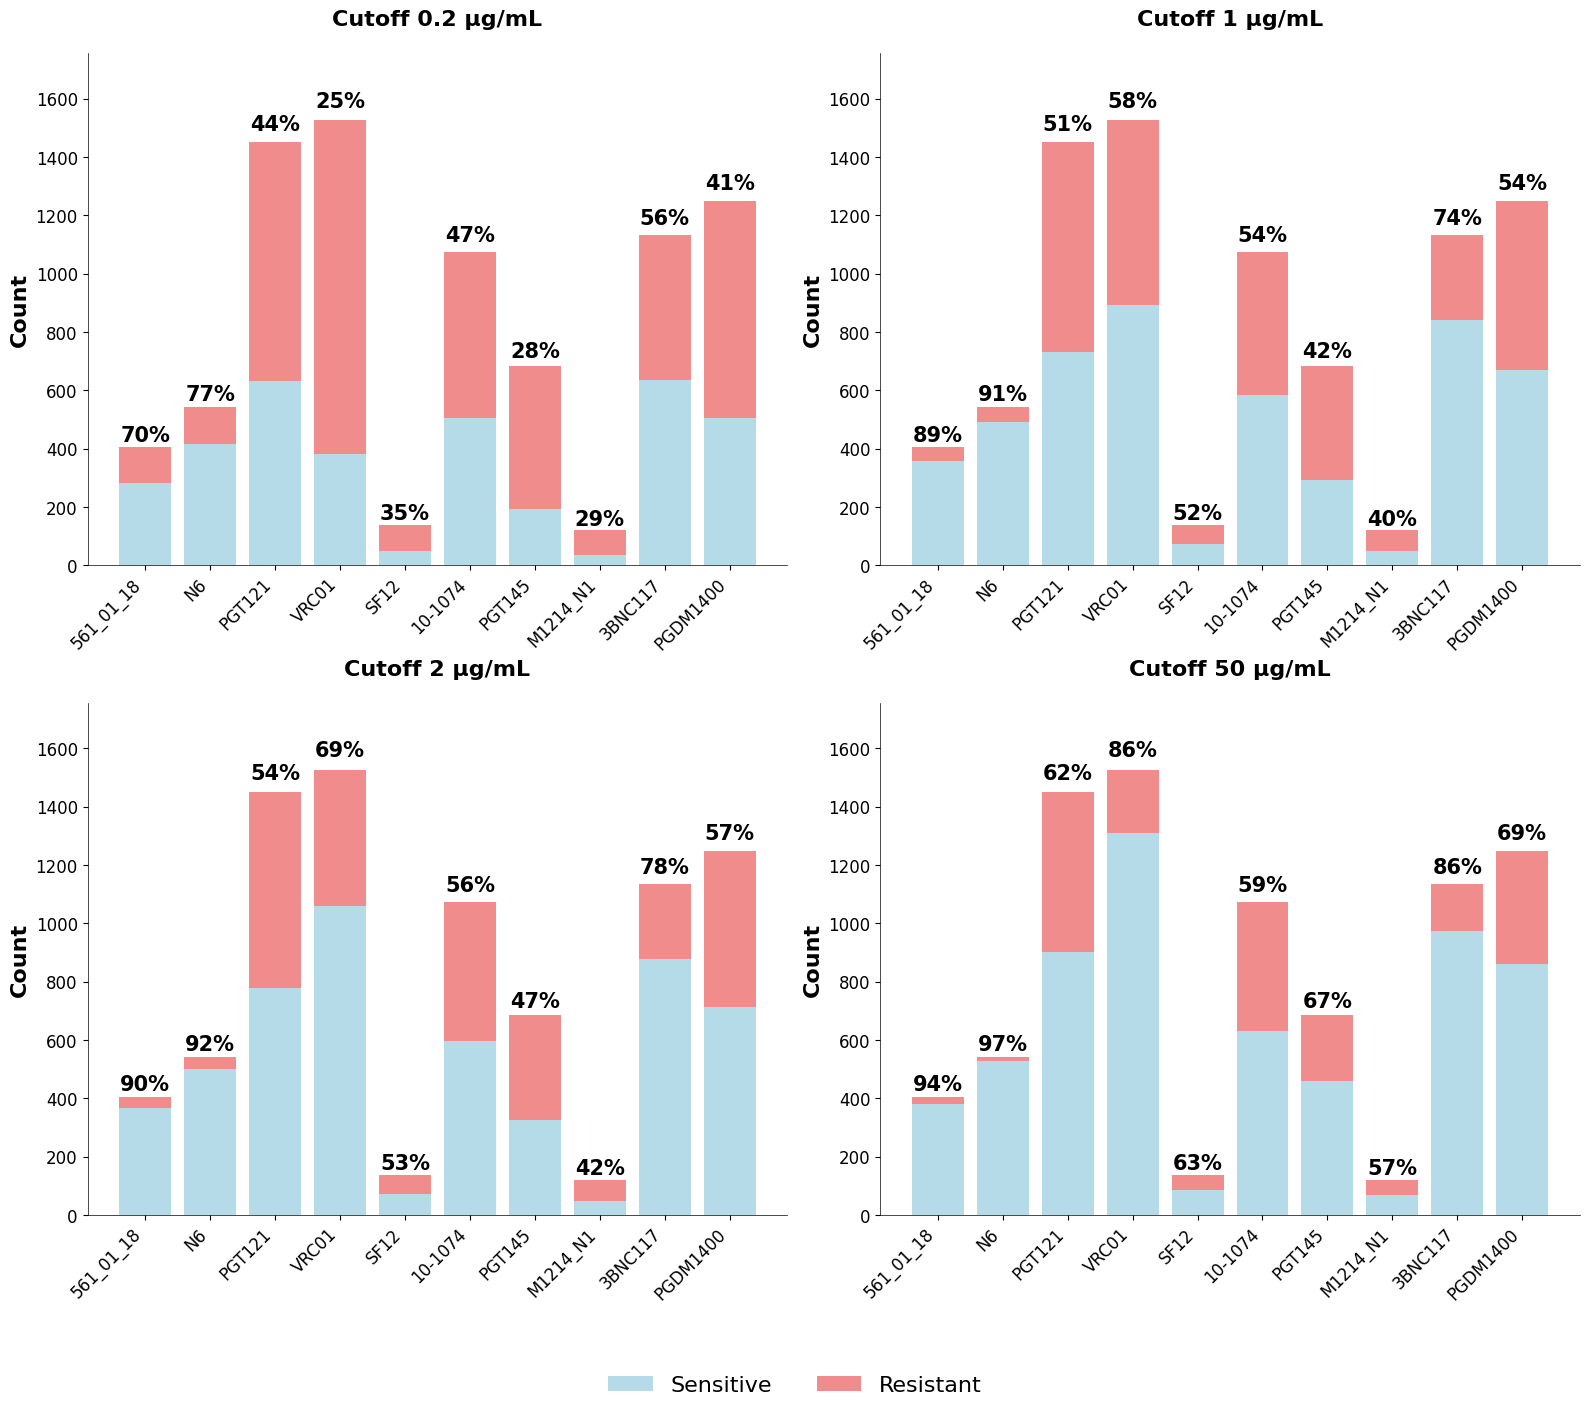

In [9]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# Define antibodies list
ANTIBODIES_LIST = [
    '561_01_18', 'N6', 'PGT121', 'VRC01', 'SF12', '10-1074', 'PGT145',
    'M1214_N1', '3BNC117', 'PGDM1400'
]

# Base directory
base_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/")

# Thresholds to process
thresholds = [0.2, 1, 2, 50]

# Set up the plot - 2x2 grid for 4 thresholds
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

# Define colors (original light blue and coral)
sensitive_color = 'lightblue'
resistant_color = 'lightcoral'

# Process each threshold file
for i, threshold in enumerate(thresholds):
    file_path = base_dir / f"catnap_flat_threshold{threshold}.json"
    # file_path = base_dir / f"catnap_flat_threshold{threshold}_removed_outliers_duplicates_geomean.json"
    
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
        
        # Count true/false for each antibody
        counts = {ab: {'true': 0, 'false': 0} for ab in ANTIBODIES_LIST}
        
        for entry in data:
            antibody = entry[1]
            label = entry[3]
            
            if antibody in ANTIBODIES_LIST:
                if label is True:
                    counts[antibody]['true'] += 1
                elif label is False:
                    counts[antibody]['false'] += 1
        
        # Prepare data for plotting
        antibodies = []
        true_counts = []
        false_counts = []
        ratios = []
        
        for antibody in ANTIBODIES_LIST:
            true_count = counts[antibody]['true']
            false_count = counts[antibody]['false']
            total = true_count + false_count
            
            if total > 0:
                antibodies.append(antibody)
                true_counts.append(true_count)
                false_counts.append(false_count)
                ratios.append(true_count / total * 100)  # Percentage sensitive
        
        # Create stacked bar chart
        x_pos = np.arange(len(antibodies))
        ax = axes[i]
        
        # Plot stacked bars
        bars1 = ax.bar(x_pos, true_counts, label='Sensitive', color=sensitive_color, alpha=0.9)
        bars2 = ax.bar(x_pos, false_counts, bottom=true_counts, label='Resistant', color=resistant_color, alpha=0.9)
        
        # Add ratio text on top of bars
        for j, (true, false, ratio) in enumerate(zip(true_counts, false_counts, ratios)):
            total = true + false
            ax.text(j, total + max(total * 0.02, 5), f'{ratio:.0f}%', 
                   ha='center', va='bottom', fontsize=15, fontweight='bold')
        
        # Customize the plot - clean publication style
        # ax.set_xlabel('Antibody', fontsize=13, fontweight='bold')
        ax.set_ylabel('Count', fontsize=16, fontweight='bold')
        ax.set_title(f'Cutoff {threshold} μg/mL', 
                    fontsize=16, fontweight='bold', pad=20)  # Increased pad to avoid overlap
        ax.set_xticks(x_pos)
        ax.set_xticklabels(antibodies, rotation=45, ha='right', fontsize=12)
        ax.tick_params(axis='y', labelsize=12)
        
        # Set y-axis limits to prevent text overlap
        max_count = max(true_counts[j] + false_counts[j] for j in range(len(true_counts)))
        ax.set_ylim(0, max_count * 1.15)  # Add 15% padding on top
        
        # Remove grid and spines for cleaner look
        ax.grid(False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(0.5)
        ax.spines['bottom'].set_linewidth(0.5)
        
        # Print table for this threshold
        print(f"\nThreshold {threshold}:")
        print("Antibody\tTrue\tFalse\t% Sensitive")
        print("-" * 40)
        for antibody in ANTIBODIES_LIST:
            true_count = counts[antibody]['true']
            false_count = counts[antibody]['false']
            total = true_count + false_count
            percent_sensitive = (true_count / total * 100) if total > 0 else 0
            print(f"{antibody}\t{true_count}\t{false_count}\t{percent_sensitive:.1f}%")
            
    except FileNotFoundError:
        print(f"File not found: {file_path}")
        continue

# Create a single legend for the entire figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.02), 
           ncol=2, fontsize=16, frameon=False)

# Remove individual legends from each subplot (only if they exist)
for ax in axes:
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

plt.tight_layout()
plt.subplots_adjust(bottom=0.12, top=0.95)  # Adjust top and bottom spacing
plt.savefig('/home/yujieq/work/ML_training/deep_hiv_ab_pred/publication_plots/sensitivity_ratios_plot_10abs.png', 
            dpi=800, bbox_inches='tight')
plt.show()

#### Supplemental table 2: 28 abs


Threshold 0.2:
Antibody	True	False	% Sensitive
----------------------------------------
561_01_18	283	122	69.9%
N6	416	126	76.8%
PGT121	632	818	43.6%
VRC01	381	1146	25.0%
SF12	48	90	34.8%
10-1074	505	569	47.0%
PGT145	193	492	28.2%
M1214_N1	35	85	29.2%
3BNC117	637	497	56.2%
PGDM1400	506	743	40.5%
VRC38.01	28	238	10.5%
PG9	318	664	32.4%
8ANC195	23	259	8.2%
35O22	51	332	13.3%
VRC34.01	71	247	22.3%
PGT135	47	348	11.9%
b12	68	848	7.4%
VRC-PG04	95	232	29.1%
PGT151	200	240	45.5%
CH01	18	403	4.3%
DH270.6	82	129	38.9%
4E10	38	963	3.8%
PGT128	291	397	42.3%
HJ16	35	301	10.4%
VRC26.25	345	268	56.3%
VRC-CH31	150	315	32.3%
10E8	211	641	24.8%
VRC07-523-W54-LS.v3	188	16	92.2%

Threshold 1:
Antibody	True	False	% Sensitive
----------------------------------------
561_01_18	359	46	88.6%
N6	491	51	90.6%
PGT121	733	717	50.6%
VRC01	892	635	58.4%
SF12	72	66	52.2%
10-1074	585	489	54.5%
PGT145	291	394	42.5%
M1214_N1	48	72	40.0%
3BNC117	841	293	74.2%
PGDM1400	669	580	53.6%
VRC38.01	39	227	14.7%
PG9	497	485	50.

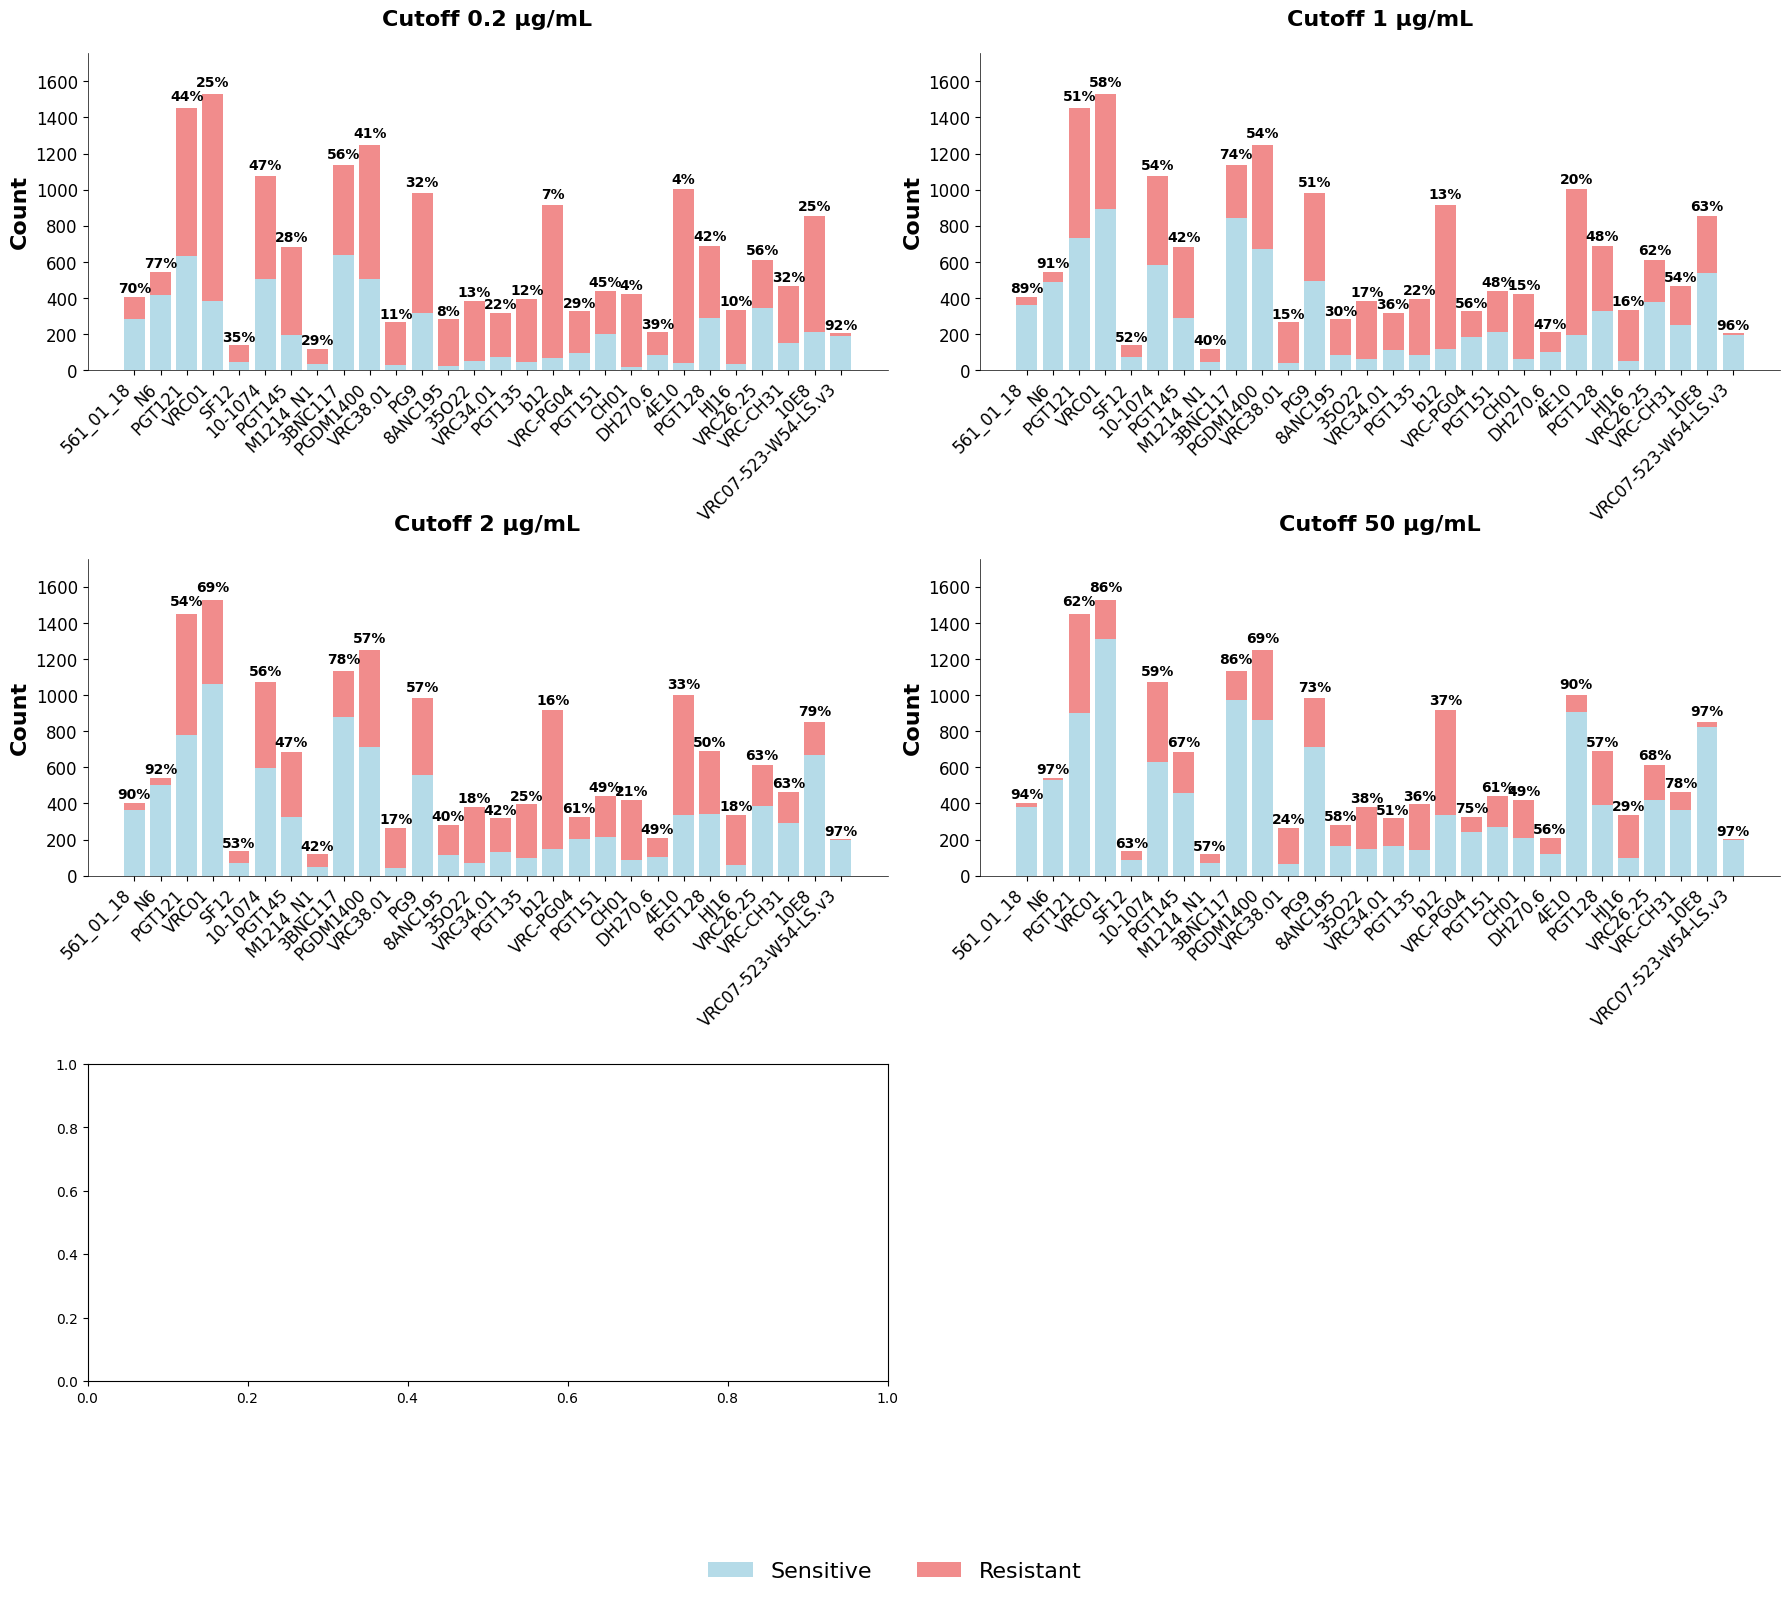

In [10]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# Define antibodies list
ANTIBODIES_LIST = [
    '561_01_18', 'N6', 'PGT121', 'VRC01', 'SF12', '10-1074', 'PGT145',
    'M1214_N1', '3BNC117', 'PGDM1400', 'VRC38.01', 'PG9', '8ANC195',
    '35O22', 'VRC34.01', 'PGT135', 'b12', 'VRC-PG04', 'PGT151', 'CH01',
    'DH270.6', '4E10', 'PGT128', 'HJ16', 'VRC26.25', 'VRC-CH31', '10E8', 'VRC07-523-W54-LS.v3'
]

# Base directory
base_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/deep_hiv_ab_pred/catnap/")

# Thresholds to process
thresholds = [0.2, 1, 2, 50]

# Set up the plot - 2x2 grid for 4 thresholds
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
axes = axes.flatten()

# Define colors (original light blue and coral)
sensitive_color = 'lightblue'
resistant_color = 'lightcoral'

# Process each threshold file
for i, threshold in enumerate(thresholds):
    file_path = base_dir / f"catnap_flat_threshold{threshold}.json"
    # file_path = base_dir / f"catnap_flat_threshold{threshold}_removed_outliers_duplicates_geomean.json"
    
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
        
        # Count true/false for each antibody
        counts = {ab: {'true': 0, 'false': 0} for ab in ANTIBODIES_LIST}
        
        for entry in data:
            antibody = entry[1]
            label = entry[3]
            
            if antibody in ANTIBODIES_LIST:
                if label is True:
                    counts[antibody]['true'] += 1
                elif label is False:
                    counts[antibody]['false'] += 1
        
        # Prepare data for plotting
        antibodies = []
        true_counts = []
        false_counts = []
        ratios = []
        
        for antibody in ANTIBODIES_LIST:
            true_count = counts[antibody]['true']
            false_count = counts[antibody]['false']
            total = true_count + false_count
            
            if total > 0:
                antibodies.append(antibody)
                true_counts.append(true_count)
                false_counts.append(false_count)
                ratios.append(true_count / total * 100)  # Percentage sensitive
        
        # Create stacked bar chart
        x_pos = np.arange(len(antibodies))
        ax = axes[i]
        
        # Plot stacked bars
        bars1 = ax.bar(x_pos, true_counts, label='Sensitive', color=sensitive_color, alpha=0.9)
        bars2 = ax.bar(x_pos, false_counts, bottom=true_counts, label='Resistant', color=resistant_color, alpha=0.9)
        
        # Add ratio text on top of bars
        for j, (true, false, ratio) in enumerate(zip(true_counts, false_counts, ratios)):
            total = true + false
            ax.text(j, total + max(total * 0.02, 5), f'{ratio:.0f}%', 
                   ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        # Customize the plot - clean publication style
        # ax.set_xlabel('Antibody', fontsize=13, fontweight='bold')
        ax.set_ylabel('Count', fontsize=16, fontweight='bold')
        ax.set_title(f'Cutoff {threshold} μg/mL', 
                    fontsize=16, fontweight='bold', pad=20)  # Increased pad to avoid overlap
        ax.set_xticks(x_pos)
        ax.set_xticklabels(antibodies, rotation=45, ha='right', fontsize=12)
        ax.tick_params(axis='y', labelsize=12)
        
        # Set y-axis limits to prevent text overlap
        max_count = max(true_counts[j] + false_counts[j] for j in range(len(true_counts)))
        ax.set_ylim(0, max_count * 1.15)  # Add 15% padding on top
        
        # Remove grid and spines for cleaner look
        ax.grid(False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(0.5)
        ax.spines['bottom'].set_linewidth(0.5)
        
        # Print table for this threshold
        print(f"\nThreshold {threshold}:")
        print("Antibody\tTrue\tFalse\t% Sensitive")
        print("-" * 40)
        for antibody in ANTIBODIES_LIST:
            true_count = counts[antibody]['true']
            false_count = counts[antibody]['false']
            total = true_count + false_count
            percent_sensitive = (true_count / total * 100) if total > 0 else 0
            print(f"{antibody}\t{true_count}\t{false_count}\t{percent_sensitive:.1f}%")
            
    except FileNotFoundError:
        print(f"File not found: {file_path}")
        continue

# After processing all thresholds, hide the empty 6th subplot
axes[5].set_visible(False)

# Create a single legend for the entire figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.02), 
           ncol=2, fontsize=16, frameon=False)

# Remove individual legends from each subplot (only if they exist)
for ax in axes:
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()


plt.tight_layout()
plt.subplots_adjust(bottom=0.12, top=0.95)  # Adjust top and bottom spacing
plt.savefig('/home/yujieq/work/ML_training/deep_hiv_ab_pred/publication_plots/sensitivity_ratios_plot_28abs.png', 
            dpi=800, bbox_inches='tight')
plt.show()

# Fig1E

### Accuracy Difference Before vs. After Curation
##### creates 3 separate plots showing accuracy differences between before and after data curation for different thresholds.


In [24]:
"""
Paired 'Before → After' ACC plots by threshold.

Inputs (Excel → Sheet2):
- Ab  : antibody name
- Thres : threshold (3 unique values expected)
- WRONG DATA     epitope with all lineage ACC : ACC before curation (mean (std))
- REMOVED OUTLIER/DUPLICATES RECORDS  epitope with all lineage ACC : ACC after curation (mean (std))

Output:
- 3 PNG images saved in /home/yujieq/work/ML_training/deep_hiv_ab_pred/publication_plots/
"""

import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- CONFIG ----------
xlsx_path = '/home/yujieq/work/ML_training/deep_hiv_ab_pred/publication_plots/Updated_Results_Oct_13.xlsx'
sheet_name = "Fig1E"

COL_AB = "Ab"
COL_THRES = "IC50"
# COL_BEFORE = "ORIGINAL CATNAP         All available data AUC"
# COL_AFTER  = "REMOVED OUTLIER/DUPLICATES RECORDS   all data            AUC"
# COL_BEFORE = "ORIGINAL CATNAP         All available data ACC"
# COL_AFTER  = "REMOVED OUTLIER/DUPLICATES RECORDS   all data            ACC"
COL_BEFORE = "ORIGINAL CATNAP         All available data MCC"
COL_AFTER  = "REMOVED OUTLIER/DUPLICATES RECORDS   all data            MCC"

output_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/publication_plots/")

# Regex to extract the mean from strings like "0.89 (0.02)"
MEAN_RE = re.compile(r"([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)")

# ---------- LOAD ----------
df = pd.read_excel(xlsx_path, sheet_name=sheet_name)

# ---------- CLEAN / PARSE ----------
def extract_mean(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.number)):
        return float(x)
    m = MEAN_RE.search(str(x))
    return float(m.group(1)) if m else np.nan

df["_before"] = df[COL_BEFORE].apply(extract_mean)
df["_after"]  = df[COL_AFTER].apply(extract_mean)

df = df.dropna(subset=[COL_AB, COL_THRES, "_before", "_after"]).copy()

# ---------- PLOT HELPERS ----------
def paired_plot(data, thres_value, out_dir):
    d = data.sort_values(COL_AB).reset_index(drop=True)
    n = len(d)

    rng = np.random.default_rng(7)
    jitter = 0.015
    x_before = np.zeros(n) + rng.normal(0, jitter, n)
    x_after  = np.ones(n)  + rng.normal(0, jitter, n)

    plt.figure(figsize=(7.5, 4.6))
    for yb, ya in zip(d["_before"], d["_after"]):
        plt.plot([0, 1], [yb, ya], color="0.65", lw=1.2, zorder=1)

    plt.scatter(x_before, d["_before"], facecolors="white", edgecolors="black", s=40, zorder=2)
    plt.scatter(x_after,  d["_after"],  facecolors="white", edgecolors="black", s=40, zorder=2)

    plt.xticks([0, 1], ["Before", "After"], fontsize=12)
    # plt.xlabel("Time", fontsize=13)
    plt.ylabel("MCC", fontsize=13)
    plt.title(f"Before vs. After Curation — Cutoff = {thres_value} μg/mL", fontsize=14, weight="bold")
    plt.xlim(-0.25, 1.25)

    y = pd.concat([d["_before"], d["_after"]])
    ypad = max(0.01, (y.max() - y.min()) * 0.08)
    plt.ylim(y.min() - ypad, y.max() + ypad)

    plt.tight_layout()
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"fig1e_mcc_cutoff_{str(thres_value).replace(' ', '_')}.png"
    plt.savefig(out_path, dpi=800)
    plt.close()
    return out_path

# ---------- RUN ----------
saved = []
for th in df[COL_THRES].dropna().unique():
    group = df[df[COL_THRES] == th]
    if len(group) > 0:
        saved.append(paired_plot(group, th, output_dir))

print("Saved plots:")
for p in saved:
    print(" -", p)


Saved plots:
 - /home/yujieq/work/ML_training/deep_hiv_ab_pred/publication_plots/fig1e_mcc_cutoff_0.2.png
 - /home/yujieq/work/ML_training/deep_hiv_ab_pred/publication_plots/fig1e_mcc_cutoff_1.0.png
 - /home/yujieq/work/ML_training/deep_hiv_ab_pred/publication_plots/fig1e_mcc_cutoff_2.0.png
 - /home/yujieq/work/ML_training/deep_hiv_ab_pred/publication_plots/fig1e_mcc_cutoff_50.0.png


# Fig1F

In [28]:
"""
Paired 'Before → After' ACC plots by threshold.

Inputs (Excel → Sheet2):
- Ab  : antibody name
- Thres : threshold (3 unique values expected)
- WRONG DATA     epitope with all lineage ACC : ACC before curation (mean (std))
- REMOVED OUTLIER/DUPLICATES RECORDS  epitope with all lineage ACC : ACC after curation (mean (std))

Output:
- 3 PNG images saved in /home/yujieq/work/ML_training/deep_hiv_ab_pred/publication_plots/
"""

import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- CONFIG ----------
xlsx_path = '/home/yujieq/work/ML_training/deep_hiv_ab_pred/publication_plots/Updated_Results_Oct_13.xlsx'
sheet_name = "Fig1F"

COL_AB = "Ab"
COL_THRES = "IC50"
COL_BEFORE = "bNap-rep ORIGINAL CATNAP                 no pretraining AUC"
COL_AFTER  = "bNap-rep REMOVED OUTLIER/DUPLICATES RECORDS              no pretraining AUC"
# COL_BEFORE = "bNap-rep ORIGINAL CATNAP                 no pretraining ACC"
# COL_AFTER  = "bNap-rep REMOVED OUTLIER/DUPLICATES RECORDS              no pretraining ACC"
# COL_BEFORE = "bNap-rep ORIGINAL CATNAP                 no pretraining MCC"
# COL_AFTER  = "bNap-rep REMOVED OUTLIER/DUPLICATES RECORDS             no pretraining MCC"

output_dir = Path("/home/yujieq/work/ML_training/deep_hiv_ab_pred/publication_plots/")

# Regex to extract the mean from strings like "0.89 (0.02)"
MEAN_RE = re.compile(r"([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)")

# ---------- LOAD ----------
df = pd.read_excel(xlsx_path, sheet_name=sheet_name)

# ---------- CLEAN / PARSE ----------
def extract_mean(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.number)):
        return float(x)
    m = MEAN_RE.search(str(x))
    return float(m.group(1)) if m else np.nan

df["_before"] = df[COL_BEFORE].apply(extract_mean)
df["_after"]  = df[COL_AFTER].apply(extract_mean)

df = df.dropna(subset=[COL_AB, COL_THRES, "_before", "_after"]).copy()

# ---------- PLOT HELPERS ----------
def paired_plot(data, thres_value, out_dir):
    d = data.sort_values(COL_AB).reset_index(drop=True)
    n = len(d)

    rng = np.random.default_rng(7)
    jitter = 0.015
    x_before = np.zeros(n) + rng.normal(0, jitter, n)
    x_after  = np.ones(n)  + rng.normal(0, jitter, n)

    plt.figure(figsize=(7.5, 4.6))
    for yb, ya in zip(d["_before"], d["_after"]):
        plt.plot([0, 1], [yb, ya], color="0.65", lw=1.2, zorder=1)

    plt.scatter(x_before, d["_before"], facecolors="white", edgecolors="black", s=40, zorder=2)
    plt.scatter(x_after,  d["_after"],  facecolors="white", edgecolors="black", s=40, zorder=2)

    plt.xticks([0, 1], ["Before", "After"], fontsize=12)
    # plt.xlabel("Time", fontsize=13)
    plt.ylabel("AUC", fontsize=13)
    plt.title(f"Before vs. After Curation — Cutoff = {thres_value} μg/mL", fontsize=14, weight="bold")
    plt.xlim(-0.25, 1.25)

    y = pd.concat([d["_before"], d["_after"]])
    ypad = max(0.01, (y.max() - y.min()) * 0.08)
    plt.ylim(y.min() - ypad, y.max() + ypad)

    plt.tight_layout()
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"fig1f_auc_cutoff_{str(thres_value).replace(' ', '_')}.png"
    plt.savefig(out_path, dpi=800)
    plt.close()
    return out_path

# ---------- RUN ----------
saved = []
for th in df[COL_THRES].dropna().unique():
    group = df[df[COL_THRES] == th]
    if len(group) > 0:
        saved.append(paired_plot(group, th, output_dir))

print("Saved plots:")
for p in saved:
    print(" -", p)


Saved plots:
 - /home/yujieq/work/ML_training/deep_hiv_ab_pred/publication_plots/fig1f_auc_cutoff_0.2.png
 - /home/yujieq/work/ML_training/deep_hiv_ab_pred/publication_plots/fig1f_auc_cutoff_1.0.png
 - /home/yujieq/work/ML_training/deep_hiv_ab_pred/publication_plots/fig1f_auc_cutoff_50.0.png


# Fig2A

Columns in the dataset:
['Ab', 'IC50', 'REMOVED OUTLIER/DUPLICATES RECORDS  epitope with all lineage MCC', 'REMOVED OUTLIER/DUPLICATES RECORDS  epitope with all lineage AUC', 'REMOVED OUTLIER/DUPLICATES RECORDS  epitope with all lineage ACC', 'REMOVED OUTLIER/DUPLICATES RECORDS  non-epitope MCC', 'REMOVED OUTLIER/DUPLICATES RECORDS  non-epitope AUC', 'REMOVED OUTLIER/DUPLICATES RECORDS  non-epitope ACC', 'REMOVED OUTLIER/DUPLICATES RECORDS   all data            MCC', 'REMOVED OUTLIER/DUPLICATES RECORDS   all data            AUC', 'REMOVED OUTLIER/DUPLICATES RECORDS   all data            ACC']
Unique antibodies: ['PGDM1400' 'PGT121' 'VRC01' 'SF12' '10-1074' '3BNC117' 'PGT145'
 'M1214_N1' '561_01_18' 'N6']
Number of unique antibodies: 10
Ab: PGDM1400, Metric: All Data, ACC: 0.89, STD: 0.03
Ab: PGDM1400, Metric: Epitope with Lineage, ACC: 0.89, STD: 0.02
Ab: PGDM1400, Metric: Non-epitope, ACC: 0.85, STD: 0.03
Ab: PGT121, Metric: All Data, ACC: 0.91, STD: 0.02
Ab: PGT121, Metric: Epitope w

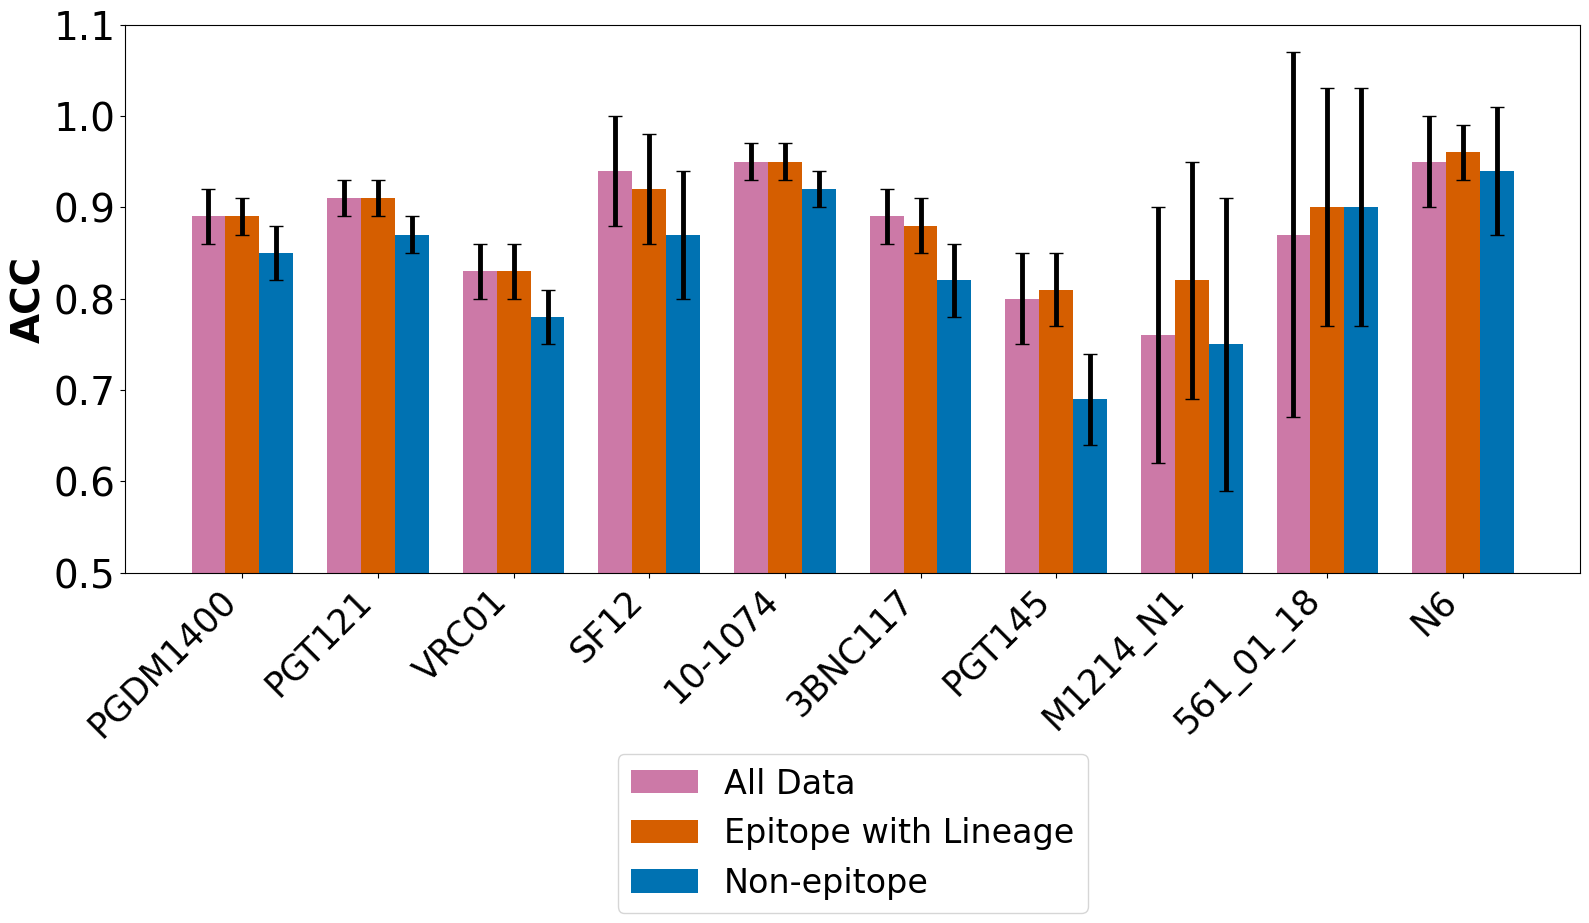

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the Excel file
file_path = '/home/yujieq/work/ML_training/deep_hiv_ab_pred/publication_plots/Updated_Results_Oct_13.xlsx'
df = pd.read_excel(file_path, sheet_name='Fig2A')

# Display the column names to verify the structure
print("Columns in the dataset:")
print(df.columns.tolist())

# Filter for cutoff 1 only and the three target columns
cutoff = 1
target_columns = [
    "REMOVED OUTLIER/DUPLICATES RECORDS   all data            ACC",
    "REMOVED OUTLIER/DUPLICATES RECORDS  epitope with all lineage ACC",
    "REMOVED OUTLIER/DUPLICATES RECORDS  non-epitope ACC"
]
column_labels = ["All Data", "Epitope with Lineage", "Non-epitope"]

# Extract unique antibodies
unique_abs = df['Ab'].unique()

print(f"Unique antibodies: {unique_abs}")
print(f"Number of unique antibodies: {len(unique_abs)}")

# Create a dictionary to store the data
data_dict = {}

for ab in unique_abs:
    data_dict[ab] = {}
    
    # Filter data for this antibody and cutoff 1
    mask = (df['Ab'] == ab) & (df['IC50'] == cutoff)
    filtered_data = df.loc[mask]
    
    if len(filtered_data) > 0:
        for i, target_col in enumerate(target_columns):
            value_str = filtered_data[target_col].iloc[0]
            # Extract ACC and std from string like "0.89 (0.03)"
            if isinstance(value_str, str) and '(' in value_str:
                acc_str, std_str = value_str.split('(')
                acc = float(acc_str.strip())
                std = float(std_str.replace(')', '').strip())
                data_dict[ab][column_labels[i]] = {'acc': acc, 'std': std}
                print(f"Ab: {ab}, Metric: {column_labels[i]}, ACC: {acc}, STD: {std}")
            else:
                print(f"Warning: Unexpected format for {ab} in {target_col}: {value_str}")
                data_dict[ab][column_labels[i]] = {'acc': np.nan, 'std': np.nan}
    else:
        print(f"Warning: No data found for {ab} at cutoff {cutoff}")
        for label in column_labels:
            data_dict[ab][label] = {'acc': np.nan, 'std': np.nan}

# Prepare data for plotting
abs_list = list(data_dict.keys())
colors = ['#CC79A7', '#D55E00', '#0072B2']  # Pinkish Purple, Orange-Red, Blue

# Create the bar plot
fig, ax = plt.subplots(figsize=(16, 10))

# Set the positions for the bars with group spacing
bar_width = 0.2
group_spacing = 0.8  # Space between antibody groups
bars_per_group = len(column_labels)

# Calculate x positions for each antibody group
x_groups = np.arange(len(abs_list)) * group_spacing
x_pos = []

for i, group_center in enumerate(x_groups):
    # Calculate positions for bars within this group
    group_positions = []
    for j in range(bars_per_group):
        # Center the bars around the group center
        pos = group_center + (j - (bars_per_group - 1) / 2) * bar_width
        group_positions.append(pos)
    x_pos.append(group_positions)

# Plot bars for each metric
bars = []
for i, metric in enumerate(column_labels):
    acc_values = [data_dict[ab][metric]['acc'] for ab in abs_list]
    std_values = [data_dict[ab][metric]['std'] for ab in abs_list]
    
    # Get positions for this metric across all antibodies
    positions = [x_pos[ab_idx][i] for ab_idx in range(len(abs_list))]
    
    bar = ax.bar(positions, acc_values, bar_width, 
                 color=colors[i], label=metric,
                 yerr=std_values, error_kw={'elinewidth': 3.5, 'capsize': 5})
    bars.append(bar)

# Customize the plot
ax.set_ylabel('ACC', fontsize=28, fontweight='bold')

# Set x-axis ticks and labels at group centers
ax.set_xticks(x_groups)
ax.set_xticklabels(abs_list, rotation=45, ha='right', fontsize=25)

# Set y-axis range
ax.set_ylim(0.5, 1.1)

# Add legend at the bottom with vertical stacking
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), 
          ncol=1, frameon=True, fontsize=24)

plt.yticks(fontsize=28)

# Adjust layout to make room for the legend
plt.tight_layout()

# Save the plot
output_path = '/home/yujieq/work/ML_training/deep_hiv_ab_pred/publication_plots/fig2a.png'
plt.savefig(output_path, dpi=800, bbox_inches='tight')
print(f"Plot saved to: {output_path}")

# Display the plot
plt.show()

# Plot resistancy time trend

In [1]:
import pandas as pd
import os
from tqdm import tqdm  # for progress bar

# Define antibodies and thresholds
antibodies = ['561_01_18', 'N6', 'PGT121', 'VRC01', 'SF12', '10-1074', 'PGT145', 
              'M1214_N1', '3BNC117', 'PGDM1400', 'VRC38.01', 'PG9', '8ANC195', 
              '35O22', 'VRC34.01', 'PGT135', 'b12', 'VRC-PG04', 'PGT151', 'CH01', 
              'DH270.6', '4E10', 'PGT128', 'HJ16', 'VRC26.25', 'VRC-CH31', '10E8', 
              'VRC07-523-W54-LS.v3', 'VRC07-523LS.v34']
thresholds = [0.2, 1, 50]

# Initialize an empty list to store all dataframes
all_data = []

# Read the ground truth labels file
gt_file_path = "work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/geomean_labels_2602strains_oct1_25.txt"
gt_df = pd.read_csv(gt_file_path, sep='\t')  # Assuming tab-separated, adjust if needed

# Loop through thresholds and antibodies
for threshold in tqdm(thresholds, desc="Processing thresholds"):
    for antibody in tqdm(antibodies, desc=f"Threshold {threshold}", leave=False):
        # Construct file path
        file_path = f"work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_69k_env_strains/threshold_{threshold}/5folds_1_repeat/Predicted_threshold{threshold}_CATNAP_69k_env_strains_fold1_repeat1_{antibody}.txt"
        
        # Check if file exists
        if not os.path.exists(file_path):
            print(f"Warning: File not found: {file_path}")
            continue
        
        try:
            # Read the prediction file
            df = pd.read_csv(file_path, sep='\t')  # Assuming tab-separated
            
            # Extract Virus, Year, and Clade from Virus_ID
            # Assuming format like: field1|field2|field3|field4|field5|Virus|Clade|field8|Year|...
            def extract_fields(virus_id):
                if pd.isna(virus_id):
                    return None, None, None
                parts = virus_id.split('|')
                # Get 6th element (index 5) for Virus
                virus = parts[5] if len(parts) > 5 else None
                # Get 9th element (index 8) for Year  
                year = parts[8] if len(parts) > 8 else None
                # Get 7th element (index 6) for Clade
                clade = parts[6] if len(parts) > 6 else None
                return virus, year, clade
            
            # Apply extraction function
            extracted = df['Virus_ID'].apply(extract_fields)
            df['Virus'] = extracted.apply(lambda x: x[0])
            df['Year'] = extracted.apply(lambda x: x[1])
            df['Clade'] = extracted.apply(lambda x: x[2])
            
            # Alternative approach (more explicit):
            # df['Virus'] = df['Virus_ID'].apply(lambda x: x.split('|')[5] if pd.notna(x) and len(x.split('|')) > 5 else None)
            # df['Year'] = df['Virus_ID'].apply(lambda x: x.split('|')[8] if pd.notna(x) and len(x.split('|')) > 8 else None)
            # df['Clade'] = df['Virus_ID'].apply(lambda x: x.split('|')[6] if pd.notna(x) and len(x.split('|')) > 6 else None)
            
            # Add Antibody and Threshold columns
            df['Antibody'] = antibody
            df['Threshold'] = threshold
            
            # Select and rename columns
            df_processed = df[['Antibody', 'Threshold', 'Virus', 'Year', 'Clade', 'State']].copy()
            df_processed = df_processed.rename(columns={'State': 'Predicted Label'})
            
            all_data.append(df_processed)
            
        except Exception as e:
            print(f"Error processing {file_path}: {e}")
            continue

# Concatenate all dataframes
if all_data:
    df_with_years = pd.concat(all_data, ignore_index=True)
    
    # Now add GT Label by matching with ground truth dataframe
    # Create a dictionary for faster lookup
    gt_dict = {}
    
    # Check what columns exist in GT dataframe
    print("\nColumns in ground truth file:")
    print(gt_df.columns.tolist())
    
    # Create lookup dictionary
    for idx, row in gt_df.iterrows():
        # Adjust column names if they differ in your file
        antibody_col = 'Antibody'  # Change if different
        virus_col = 'Virus'  # Change if different
        threshold_col = 'Threshold'  # Change if different
        label_col = 'Label_Sensitive/Resistant'  # Change if different
        
        key = (str(row[antibody_col]), str(row[virus_col]), float(row[threshold_col]))
        gt_dict[key] = row[label_col]
    
    # Match GT labels
    df_with_years['GT Label'] = None
    
    for idx, row in tqdm(df_with_years.iterrows(), total=len(df_with_years), desc="Matching GT labels"):
        key = (str(row['Antibody']), str(row['Virus']), float(row['Threshold']))
        if key in gt_dict:
            df_with_years.at[idx, 'GT Label'] = gt_dict[key]
    
    # Convert empty matches to NaN
    df_with_years['GT Label'] = df_with_years['GT Label'].replace('', pd.NA)
    
    # Reorder columns for better organization
    column_order = ['Antibody', 'Threshold', 'Virus', 'Year', 'Clade', 'Predicted Label', 'GT Label']
    df_with_years = df_with_years[column_order]
    
    # Display summary
    print(f"\nDataframe created with {len(df_with_years)} rows")
    print(f"Columns: {df_with_years.columns.tolist()}")
    print(f"\nFirst few rows:")
    print(df_with_years.head())
    print(f"\nUnique clades found:")
    print(df_with_years['Clade'].value_counts().head(10))
    print(f"\nGT Label distribution (non-NaN):")
    print(df_with_years['GT Label'].value_counts(dropna=False))
    
    # Optional: Save to file
    # df_with_years.to_csv("df_with_years_with_clade.csv", index=False)
    
else:
    print("No data was processed. Check file paths and existence.")

Processing thresholds: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:19<00:00,  6.50s/it]



Columns in ground truth file:
['Antibody', 'Virus', 'GeoMean_IC50', 'Threshold', 'Label_0/1', 'Label_Sensitive/Resistant']


Matching GT labels: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5992299/5992299 [02:21<00:00, 42352.23it/s]



Dataframe created with 5992299 rows
Columns: ['Antibody', 'Threshold', 'Virus', 'Year', 'Clade', 'Predicted Label', 'GT Label']

First few rows:
    Antibody  Threshold      Virus    Year Clade Predicted Label GT Label
0  561_01_18        0.2       81NJ  1981.0     B       sensitive     None
1  561_01_18        0.2  ES4v1ed10  2004.0     B       sensitive     None
2  561_01_18        0.2  ES2v2ed11  2004.0     B       sensitive     None
3  561_01_18        0.2      81CA2  1981.0     B       sensitive     None
4  561_01_18        0.2      82CAN  1982.0     B       sensitive     None

Unique clades found:
Clade
B        2306805
C        1781499
01_AE     586554
F1        345651
N/A       240033
BF1       196533
A1         91176
A1B        61248
D          50460
02_AG      26535
Name: count, dtype: int64

GT Label distribution (non-NaN):
GT Label
None         5983494
sensitive       4521
resistant       4284
Name: count, dtype: int64


In [2]:
df_with_years

,Antibody,Threshold,Virus,Year,Clade,Predicted Label,GT Label
0,561_01_18,0.2,81NJ,1981.0,B,sensitive,None
1,561_01_18,0.2,ES4v1ed10,2004.0,B,sensitive,None
2,561_01_18,0.2,ES2v2ed11,2004.0,B,sensitive,None
3,561_01_18,0.2,81CA2,1981.0,B,sensitive,None
4,561_01_18,0.2,82CAN,1982.0,B,sensitive,None
...,...,...,...,...,...,...,...
5992294,VRC07-523LS.v34,50.0,CA9,1993.0,O,resistant,None
5992295,VRC07-523LS.v34,50.0,341HA,1994.0,O,resistant,None
5992296,VRC07-523LS.v34,50.0,655HA,1994.0,O,sensitive,None
5992297,VRC07-523LS.v34,50.0,267Ha_276Ha,1994.0,O,sensitive,None


In [3]:
df_with_years[~df_with_years['GT Label'].isna()]

,Antibody,Threshold,Virus,Year,Clade,Predicted Label,GT Label
54,561_01_18,0.2,JRCSF,1986.0,B,sensitive,sensitive
101,561_01_18,0.2,PVO_4,1996.0,B,sensitive,sensitive
165,561_01_18,0.2,TRO_11,1995.0,B,sensitive,sensitive
294,561_01_18,0.2,6535_3,1995.0,B,sensitive,sensitive
457,561_01_18,0.2,Q23_17,1994.0,A1,sensitive,sensitive
...,...,...,...,...,...,...,...
5926188,VRC07-523LS.v34,50.0,CNE20,2007.0,07_BC,sensitive,sensitive
5926228,VRC07-523LS.v34,50.0,BJOX028000_10_3,2007.0,01_AE,sensitive,sensitive
5926291,VRC07-523LS.v34,50.0,CNE56,2007.0,01_AE,sensitive,sensitive
5926414,VRC07-523LS.v34,50.0,CNE55,2007.0,01_AE,sensitive,sensitive


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Filter rows with Year values
df_with_years = df_with_years[df_with_years['Year'].notna()]

# Convert Year to numeric
df_with_years['Year'] = pd.to_numeric(df_with_years['Year'], errors='coerce')
df_with_years = df_with_years[df_with_years['Year'].notna()]

# Define year groups
def assign_year_group(year):
    if  year <= 2010:
        return 1
    elif year <= 2015:
        return 2
    elif year <= 2020:
        return 3
    else:
        return 4

# Apply year grouping
df_with_years['Year_Group'] = df_with_years['Year'].apply(assign_year_group)

df_with_years

,Antibody,Threshold,Virus,Year,Clade,Predicted Label,GT Label,Year_Group
0,561_01_18,0.2,81NJ,1981.0,B,sensitive,None,1
1,561_01_18,0.2,ES4v1ed10,2004.0,B,sensitive,None,1
2,561_01_18,0.2,ES2v2ed11,2004.0,B,sensitive,None,1
3,561_01_18,0.2,81CA2,1981.0,B,sensitive,None,1
4,561_01_18,0.2,82CAN,1982.0,B,sensitive,None,1
...,...,...,...,...,...,...,...,...
5992294,VRC07-523LS.v34,50.0,CA9,1993.0,O,resistant,None,1
5992295,VRC07-523LS.v34,50.0,341HA,1994.0,O,resistant,None,1
5992296,VRC07-523LS.v34,50.0,655HA,1994.0,O,sensitive,None,1
5992297,VRC07-523LS.v34,50.0,267Ha_276Ha,1994.0,O,sensitive,None,1


In [5]:
df_with_years['plot_label'] = np.where(
    df_with_years['GT Label'].notna(),
    df_with_years['GT Label'],
    df_with_years['Predicted Label']
)

df_with_years

,Antibody,Threshold,Virus,Year,Clade,Predicted Label,GT Label,Year_Group,plot_label
0,561_01_18,0.2,81NJ,1981.0,B,sensitive,None,1,sensitive
1,561_01_18,0.2,ES4v1ed10,2004.0,B,sensitive,None,1,sensitive
2,561_01_18,0.2,ES2v2ed11,2004.0,B,sensitive,None,1,sensitive
3,561_01_18,0.2,81CA2,1981.0,B,sensitive,None,1,sensitive
4,561_01_18,0.2,82CAN,1982.0,B,sensitive,None,1,sensitive
...,...,...,...,...,...,...,...,...,...
5992294,VRC07-523LS.v34,50.0,CA9,1993.0,O,resistant,None,1,resistant
5992295,VRC07-523LS.v34,50.0,341HA,1994.0,O,resistant,None,1,resistant
5992296,VRC07-523LS.v34,50.0,655HA,1994.0,O,sensitive,None,1,sensitive
5992297,VRC07-523LS.v34,50.0,267Ha_276Ha,1994.0,O,sensitive,None,1,sensitive


In [6]:
df_with_years[df_with_years['GT Label'].isna()]

,Antibody,Threshold,Virus,Year,Clade,Predicted Label,GT Label,Year_Group,plot_label
0,561_01_18,0.2,81NJ,1981.0,B,sensitive,None,1,sensitive
1,561_01_18,0.2,ES4v1ed10,2004.0,B,sensitive,None,1,sensitive
2,561_01_18,0.2,ES2v2ed11,2004.0,B,sensitive,None,1,sensitive
3,561_01_18,0.2,81CA2,1981.0,B,sensitive,None,1,sensitive
4,561_01_18,0.2,82CAN,1982.0,B,sensitive,None,1,sensitive
...,...,...,...,...,...,...,...,...,...
5992294,VRC07-523LS.v34,50.0,CA9,1993.0,O,resistant,None,1,resistant
5992295,VRC07-523LS.v34,50.0,341HA,1994.0,O,resistant,None,1,resistant
5992296,VRC07-523LS.v34,50.0,655HA,1994.0,O,sensitive,None,1,sensitive
5992297,VRC07-523LS.v34,50.0,267Ha_276Ha,1994.0,O,sensitive,None,1,sensitive


Subset1 (GT Label not NaN) size: 1083
Subset2 (GT Label is NaN) size: 1104675

Creating plot for threshold 0.2


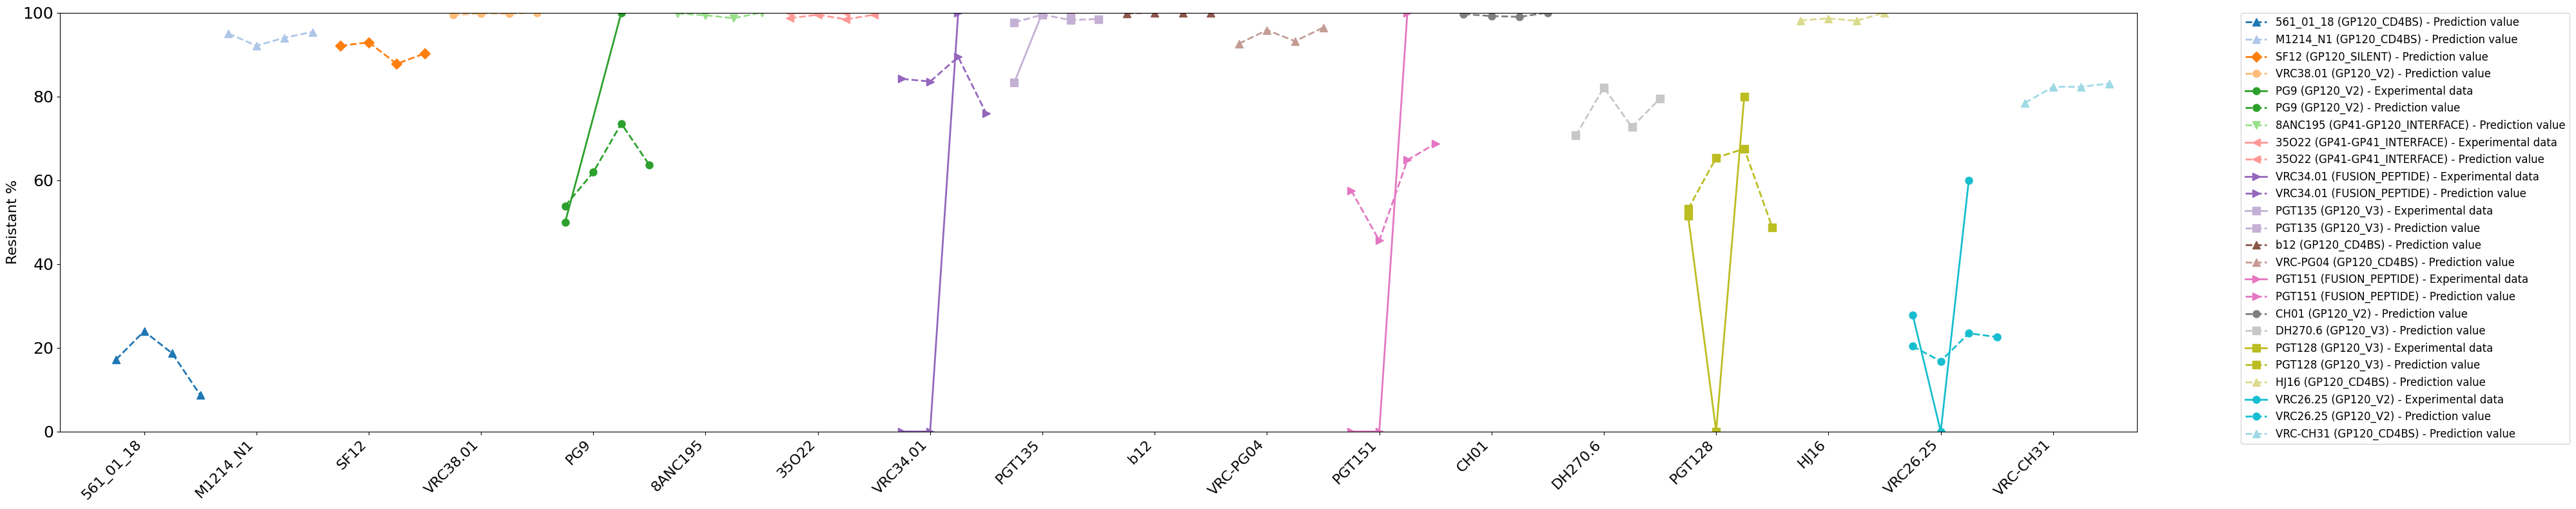

Saved plot: /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_69k_env_strains/antibody_year_trend_threshold_0.2.png

Creating plot for threshold 1.0


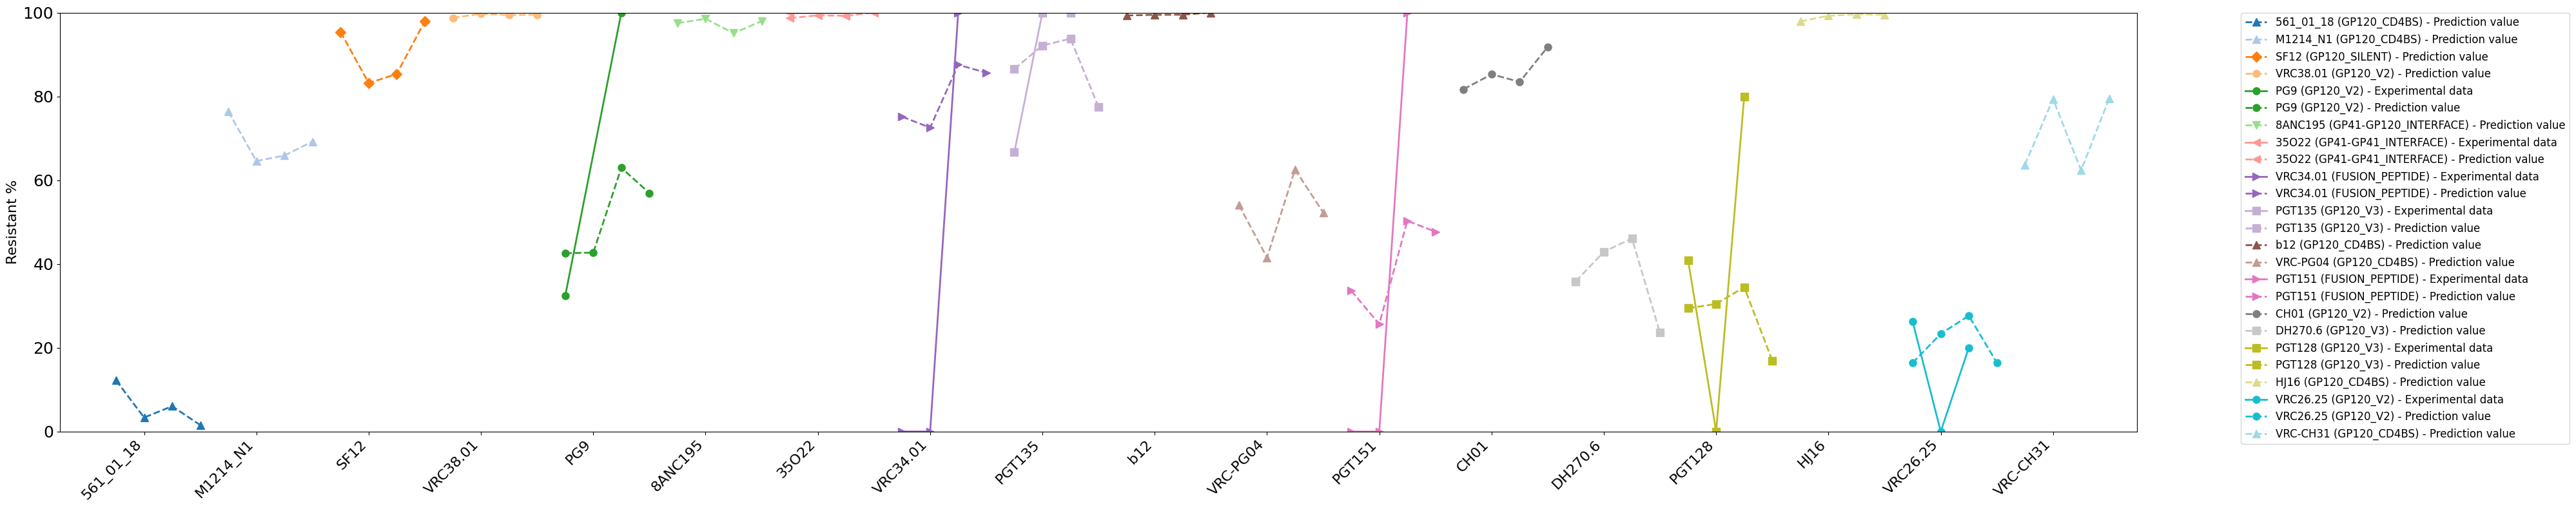

Saved plot: /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_69k_env_strains/antibody_year_trend_threshold_1.0.png

Creating plot for threshold 50.0


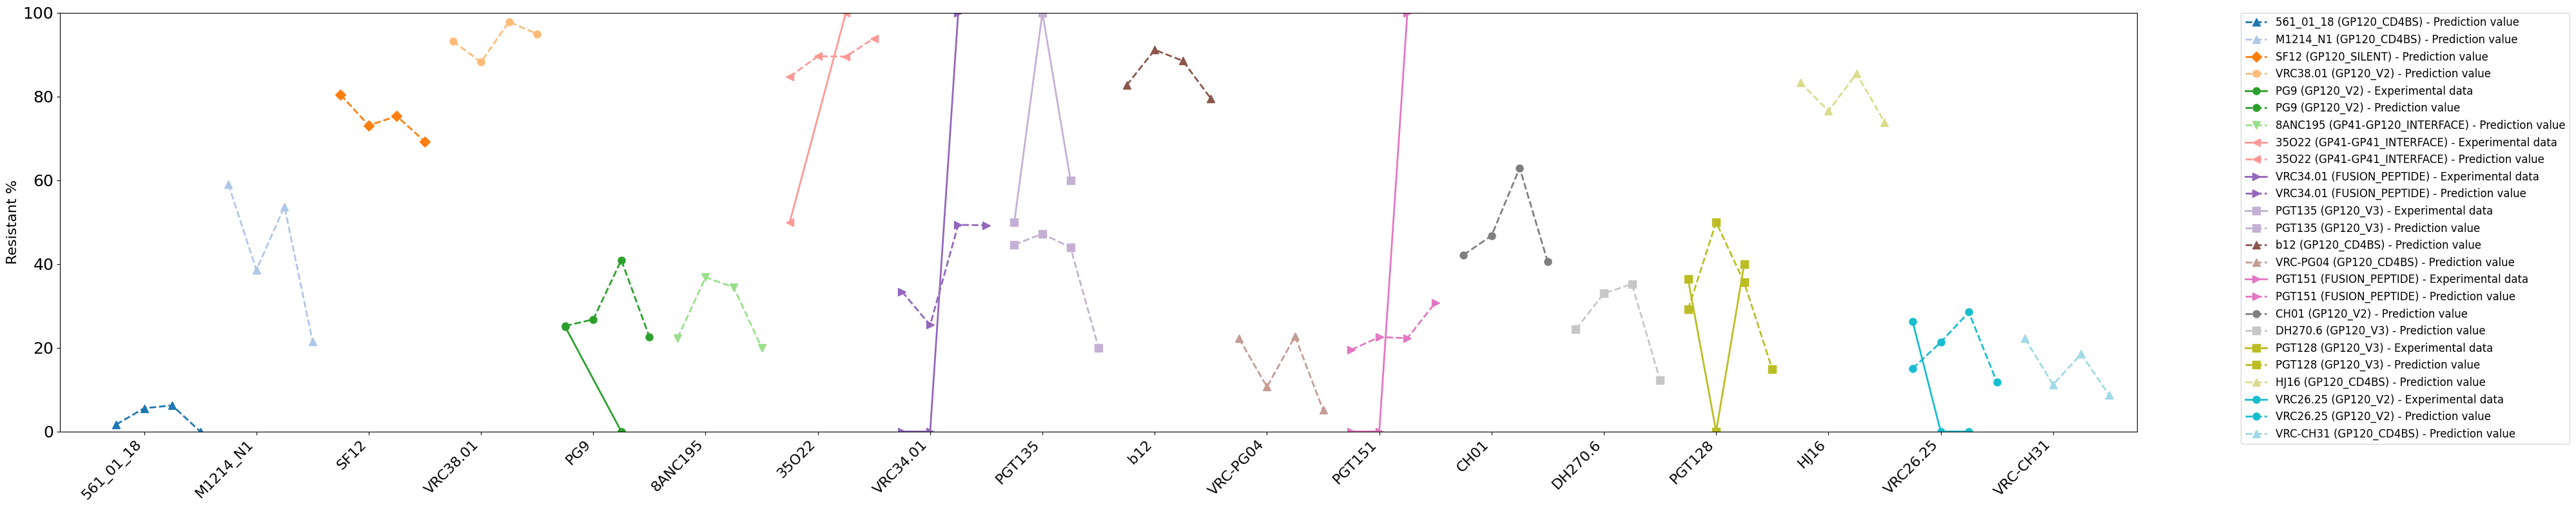

Saved plot: /home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_69k_env_strains/antibody_year_trend_threshold_50.0.png


In [13]:
# Filter antibodies to the specified list
target_antibodies_main_fig = ['PGT121', 'VRC01', '10-1074', 'PGT145', 'N6', '3BNC117', 'PGDM1400', '10E8', '4E10', 'VRC07-523-W54-LS.v3']
target_antibodies_suppl_fig = ['561_01_18', 'M1214_N1', 'SF12', 'VRC38.01', 'PG9', '8ANC195', '35O22', 'VRC34.01', 'PGT135', 'b12', 'VRC-PG04', 'PGT151', 'CH01', 
                     'DH270.6', 'PGT128', 'HJ16', 'VRC26.25', 'VRC-CH31']

# df_filtered = df_with_years[df_with_years['Antibody'].isin(target_antibodies_main_fig)]
df_filtered = df_with_years[df_with_years['Antibody'].isin(target_antibodies_suppl_fig)]

df_filtered = df_filtered[df_filtered['Clade']== 'C']

# Create 2 subsets from df_filtered
subset1 = df_filtered[df_filtered['GT Label'].notna()]  # GT Label is not NaN
subset2 = df_filtered[df_filtered['GT Label'].isna()]   # GT Label is NaN

print(f"Subset1 (GT Label not NaN) size: {len(subset1)}")
print(f"Subset2 (GT Label is NaN) size: {len(subset2)}")

# Define epitope mapping for all 29 antibodies
epitope_mapping = {
    'PGDM1400': 'GP120_V2',
    'PGT121': 'GP120_V3', 
    'VRC01': 'GP120_CD4BS',
    'SF12': 'GP120_SILENT',
    '10-1074': 'GP120_V3',
    '3BNC117': 'GP120_CD4BS',
    'PGT145': 'GP120_V2',
    'M1214_N1': 'GP120_CD4BS',
    '561_01_18': 'GP120_CD4BS',
    'N6': 'GP120_CD4BS',
    'VRC38.01': 'GP120_V2',
    'PG9': 'GP120_V2',
    '8ANC195': 'GP41-GP120_INTERFACE',
    '35O22': 'GP41-GP41_INTERFACE',
    'VRC34.01': 'FUSION_PEPTIDE',
    'PGT135': 'GP120_V3',
    'b12': 'GP120_CD4BS',
    'VRC-PG04': 'GP120_CD4BS',
    'PGT151': 'FUSION_PEPTIDE',
    'CH01': 'GP120_V2',
    'DH270.6': 'GP120_V3',
    '4E10': 'GP41_MPER',
    'PGT128': 'GP120_V3',
    'HJ16': 'GP120_CD4BS',
    'VRC26.25': 'GP120_V2',
    'VRC-CH31': 'GP120_CD4BS',
    '10E8': 'GP41_MPER',
    'VRC07-523-W54-LS.v3': 'GP120_CD4BS',
    'VRC07-523LS.v34': 'GP120_CD4BS'
}

# Define markers for all epitopes
epitope_markers = {
    'GP120_V2': 'o',
    'GP120_V3': 's',
    'GP120_CD4BS': '^',
    'GP120_SILENT': 'D',
    'GP41-GP120_INTERFACE': 'v',
    'GP41-GP41_INTERFACE': '<',
    'FUSION_PEPTIDE': '>',
    'GP41_MPER': 'X'
}

# Map year groups to x-axis values (merged groups 1 and 2)
year_group_to_x = {
    1: 1,  # Before 2010 (merged groups 1 and 2)
    2: 2,  # 2010-2015
    3: 3,  # 2015-2020
    4: 4   # After 2020
}

# Create separate plots for each threshold
thresholds = df_filtered['Threshold'].unique()

for threshold in thresholds:
    print(f"\nCreating plot for threshold {threshold}")
    
    # Filter data for current threshold
    threshold_subset1 = subset1[subset1['Threshold'] == threshold]
    threshold_subset2 = subset2[subset2['Threshold'] == threshold]
    
    # Calculate resistant percentage for each antibody and year group for both subsets
    results_subset1 = []
    results_subset2 = []
    
    # for antibody in target_antibodies_main_fig:
    for antibody in target_antibodies_suppl_fig:
        # Process subset1 (GT Label not NaN)
        antibody_data1 = threshold_subset1[threshold_subset1['Antibody'] == antibody]
        
        # Merge year groups 1 and 2
        for year_group in [1, 2, 3, 4]:
            group_data = antibody_data1[antibody_data1['Year_Group'] == year_group]
            if len(group_data) > 0:
                total_count = len(group_data)
                resistant_count = len(group_data[group_data['plot_label'] == 'resistant'])
                resistant_percentage = (resistant_count / total_count) * 100
                
                # Use merged x-value
                x_value = year_group_to_x[year_group]
                
                results_subset1.append({
                    'Antibody': antibody,
                    'Epitope': epitope_mapping[antibody],
                    'Year_Group': year_group,
                    'X_Value': x_value,
                    'Resistant_Percentage': resistant_percentage,
                    'Total_Count': total_count,
                    'Resistant_Count': resistant_count
                })
        
        # Process subset2 (GT Label is NaN)
        antibody_data2 = threshold_subset2[threshold_subset2['Antibody'] == antibody]
        
        # Merge year groups 1 and 2
        for year_group in [1, 2, 3, 4]:
            group_data = antibody_data2[antibody_data2['Year_Group'] == year_group]
            if len(group_data) > 0:
                total_count = len(group_data)
                resistant_count = len(group_data[group_data['plot_label'] == 'resistant'])
                resistant_percentage = (resistant_count / total_count) * 100
                
                # Use merged x-value
                x_value = year_group_to_x[year_group]
                
                results_subset2.append({
                    'Antibody': antibody,
                    'Epitope': epitope_mapping[antibody],
                    'Year_Group': year_group,
                    'X_Value': x_value,
                    'Resistant_Percentage': resistant_percentage,
                    'Total_Count': total_count,
                    'Resistant_Count': resistant_count
                })
    
    if not results_subset1 and not results_subset2:
        print(f"No data for threshold {threshold}")
        continue
        
    results_df1 = pd.DataFrame(results_subset1)
    results_df2 = pd.DataFrame(results_subset2)
    
    # Create the plot
    plt.figure(figsize=(40, 8))
    
    # Get unique antibodies for coloring (each antibody gets unique color)
    # antibodies = target_antibodies_main_fig
    antibodies = target_antibodies_suppl_fig
    colors = plt.cm.tab20(np.linspace(0, 1, len(antibodies)))
    color_dict = dict(zip(antibodies, colors))
    
    # Define the x-axis positions for each antibody with reduced gap
    antibody_positions = {ab: i * 4 for i, ab in enumerate(antibodies)}  # Reduced from 10 to 6
    
    # Plot each antibody with epitope-specific markers and unique colors
    for antibody in antibodies:
        base_pos = antibody_positions[antibody]
        epitope = epitope_mapping[antibody]
        
        # Get data for this antibody from both subsets
        antibody_data1 = results_df1[results_df1['Antibody'] == antibody].sort_values('X_Value')
        antibody_data2 = results_df2[results_df2['Antibody'] == antibody].sort_values('X_Value')
        
        # Calculate x positions for year groups within this antibody
        x_positions1 = [base_pos + x for x in antibody_data1['X_Value']]
        x_positions2 = [base_pos + x for x in antibody_data2['X_Value']]
        
        # Plot subset1 (solid line)
        if len(antibody_data1) > 1:
            plt.plot(x_positions1, antibody_data1['Resistant_Percentage'], 
                    marker=epitope_markers[epitope], linewidth=2, markersize=8, 
                    color=color_dict[antibody], linestyle='-', 
                    label=f"{antibody} ({epitope}) - Experimental data")
        
        # Plot subset2 (dashed line)
        if len(antibody_data2) > 1:
            plt.plot(x_positions2, antibody_data2['Resistant_Percentage'], 
                    marker=epitope_markers[epitope], linewidth=2, markersize=8, 
                    color=color_dict[antibody], linestyle='--', 
                    label=f"{antibody} ({epitope}) - Prediction value")
    
    # Customize the plot
    # plt.xlabel('Antibody', fontsize=12)
    plt.ylabel('Resistant %', fontsize=16)
    
    # Set x-axis ticks and labels - only antibody names
    plt.xticks([antibody_positions[ab] + 2 for ab in antibodies], antibodies, rotation=45, ha='right', fontsize=16)
    plt.yticks(fontsize=18)
    
    # Set x-axis limits to reduce whitespace
    plt.xlim(antibody_positions[antibodies[0]] - 1, antibody_positions[antibodies[-1]] + 5)
    
    plt.ylim(0, 100)
    
    # Create legend
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=12)
    
    plt.tight_layout()
    
    # Save the plot
    output_filename = f"/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_69k_env_strains/antibody_year_trend_threshold_{threshold}.png"
    plt.savefig(output_filename, dpi=800, bbox_inches='tight')
    plt.show()
    
    print(f"Saved plot: {output_filename}")

In [7]:
df_with_years[df_with_years['Clade'] == 'A']

,Antibody,Threshold,Virus,Year,Clade,Predicted Label,GT Label,Year_Group,plot_label
1508,561_01_18,0.2,04ZASK162B1,2004.0,A,sensitive,None,1,sensitive
3395,561_01_18,0.2,707PKE02N3,2009.0,A,sensitive,None,1,sensitive
4754,561_01_18,0.2,HIV_CH_BID-V3538_2003,2003.0,A,sensitive,None,1,sensitive
7158,561_01_18,0.2,P4039,1987.0,A,sensitive,None,1,sensitive
70385,N6,0.2,04ZASK162B1,2004.0,A,sensitive,None,1,sensitive
...,...,...,...,...,...,...,...,...,...
5861703,VRC07-523-W54-LS.v3,50.0,P4039,1987.0,A,sensitive,None,1,sensitive
5924930,VRC07-523LS.v34,50.0,04ZASK162B1,2004.0,A,sensitive,None,1,sensitive
5926817,VRC07-523LS.v34,50.0,707PKE02N3,2009.0,A,sensitive,None,1,sensitive
5928176,VRC07-523LS.v34,50.0,HIV_CH_BID-V3538_2003,2003.0,A,sensitive,None,1,sensitive


In [9]:
df_with_years.to_csv('/home/yujieq/work/ML_training/deep_hiv_ab_pred/final_model_predictions/CATNAP_strains/prediction_results/CATNAP_69k_env_strains/combined_predictions_with_years.csv', index=False)

DISTRIBUTION OF ALL CLADE VALUES
Total rows in df_with_years: 5992299
Number of unique Clade values: 346

Clade distribution (counts):
----------------------------------------
  'B': 2,306,805 (38.50%)
  'C': 1,781,499 (29.73%)
  '01_AE': 586,554 (9.79%)
  'F1': 345,651 (5.77%)
  'N/A': 240,033 (4.01%)
  'BF1': 196,533 (3.28%)
  'A1': 91,176 (1.52%)
  'A1B': 61,248 (1.02%)
  'D': 50,460 (0.84%)
  '02_AG': 26,535 (0.44%)
  'A6': 25,056 (0.42%)
  'F2': 17,226 (0.29%)
  'G': 16,617 (0.28%)
  'A1D': 15,834 (0.26%)
  '07_BC': 13,311 (0.22%)
  '01B': 11,049 (0.18%)
  'A1C': 10,701 (0.18%)
  '0107': 9,918 (0.17%)
  'BC': 9,570 (0.16%)
  '07BC': 8,091 (0.14%)
  '01BC': 6,960 (0.12%)
  'O': 6,873 (0.11%)
  '08_BC': 6,177 (0.10%)
  '85_BC': 4,350 (0.07%)
  '07C': 4,089 (0.07%)
  'A1CD': 3,567 (0.06%)
  '63_02A6': 3,306 (0.06%)
  '02A1': 3,132 (0.05%)
  'CD': 2,958 (0.05%)
  'U': 2,262 (0.04%)
  '06_cpx': 2,088 (0.03%)
  '11_cpx': 2,088 (0.03%)
  '02A': 2,001 (0.03%)
  '35_A1D': 1,914 (0.03%)
  '

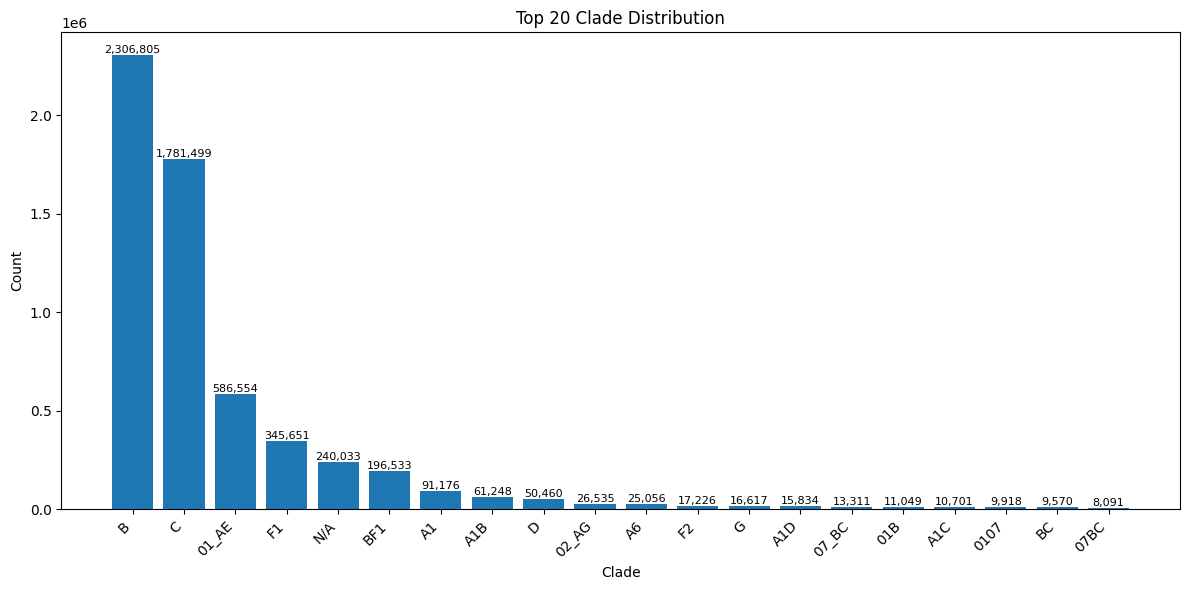

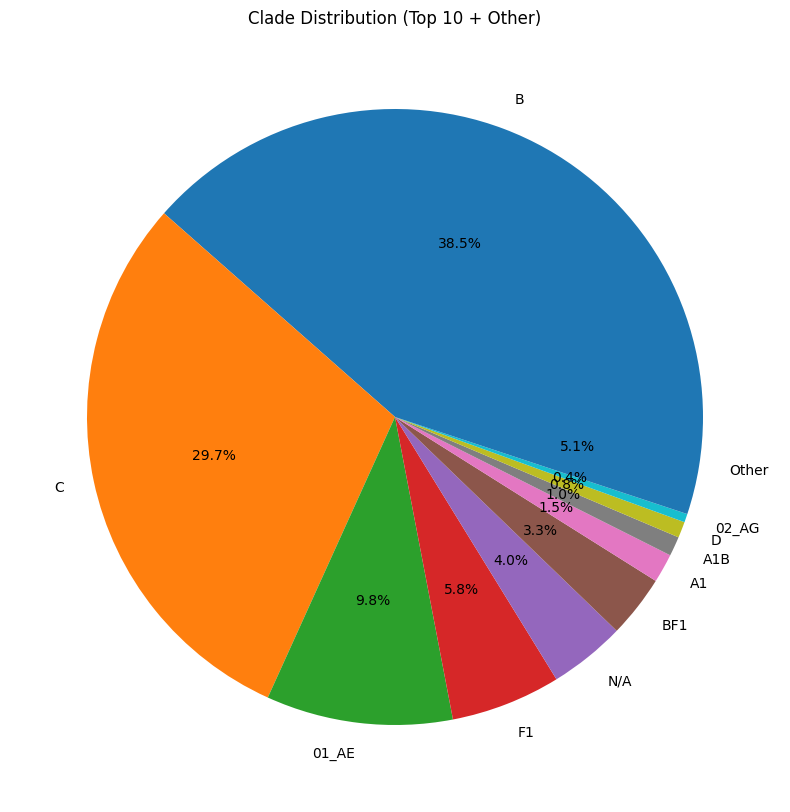

In [10]:
# Check the distribution of all Clade values
print("=" * 60)
print("DISTRIBUTION OF ALL CLADE VALUES")
print("=" * 60)

# Check if Clade column exists
if 'Clade' in df_with_years.columns:
    # Get value counts
    clade_counts = df_with_years['Clade'].value_counts(dropna=False)
    
    # Get percentages
    clade_percentages = df_with_years['Clade'].value_counts(dropna=True, normalize=True) * 100
    
    print(f"Total rows in df_with_years: {len(df_with_years)}")
    print(f"Number of unique Clade values: {df_with_years['Clade'].nunique(dropna=False)}")
    print("\nClade distribution (counts):")
    print("-" * 40)
    
    for clade, count in clade_counts.items():
        if pd.isna(clade):
            percentage = (count / len(df_with_years)) * 100
            print(f"  NaN/Null: {count:,} ({percentage:.2f}%)")
        else:
            percentage = (count / len(df_with_years)) * 100
            print(f"  '{clade}': {count:,} ({percentage:.2f}%)")
    
    print("\nTop 20 most frequent Clades:")
    print("-" * 40)
    # Filter out NaN for top 20
    top_clades = df_with_years['Clade'].value_counts(dropna=True).head(20)
    for clade, count in top_clades.items():
        percentage = (count / len(df_with_years)) * 100
        print(f"  '{clade}': {count:,} ({percentage:.2f}%)")
    
    # Check specifically for 'A' clade
    print("\n" + "=" * 60)
    print("SPECIFIC ANALYSIS FOR CLADE 'A'")
    print("=" * 60)
    
    a_clade_count = len(df_with_years[df_with_years['Clade'] == 'A'])
    print(f"Rows with Clade == 'A': {a_clade_count:,}")
    print(f"Percentage of total: {(a_clade_count/len(df_with_years)*100):.2f}%")
    
    # Show sample of rows with Clade 'A'
    if a_clade_count > 0:
        print(f"\nSample of rows with Clade 'A' (first 5):")
        print(df_with_years[df_with_years['Clade'] == 'A'].head())
    
    # Check for case variations of 'A'
    print("\nChecking for case variations of 'A':")
    unique_clades_lower = df_with_years['Clade'].dropna().astype(str).str.lower().unique()
    a_variations = [c for c in unique_clades_lower if 'a' in c or 'A' in c]
    print(f"Clade values containing 'a' (case-insensitive): {a_variations}")
    
    # Check for whitespace or extra characters
    print("\nChecking for 'A' with whitespace or extra characters:")
    a_like_clades = df_with_years['Clade'].dropna().unique()
    a_like = [c for c in a_like_clades if 'A' in str(c) or 'a' in str(c)]
    print(f"Clade values containing 'A' or 'a': {a_like}")
    
    # If 'A' count is 0, show what the actual values might be
    if a_clade_count == 0:
        print(f"\n⚠️  WARNING: No rows found with Clade == 'A'")
        print("Check if 'A' might be stored differently (e.g., 'a', 'A ', 'A1', etc.)")
        print("\nMost common Clade values (showing all if < 30):")
        all_clades = df_with_years['Clade'].value_counts(dropna=True)
        if len(all_clades) <= 30:
            for clade, count in all_clades.items():
                percentage = (count / len(df_with_years)) * 100
                print(f"  '{clade}': {count:,} ({percentage:.2f}%)")
    
    # Visualize the distribution
    import matplotlib.pyplot as plt
    
    # Create a bar chart for top 20 clades
    plt.figure(figsize=(12, 6))
    top_20 = df_with_years['Clade'].value_counts(dropna=True).head(20)
    
    # Create bars
    bars = plt.bar(range(len(top_20)), top_20.values)
    plt.xticks(range(len(top_20)), top_20.index, rotation=45, ha='right')
    plt.xlabel('Clade')
    plt.ylabel('Count')
    plt.title('Top 20 Clade Distribution')
    plt.tight_layout()
    
    # Add count labels on top of bars
    for bar, count in zip(bars, top_20.values):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{count:,}', ha='center', va='bottom', fontsize=8)
    
    plt.show()
    
    # Create a pie chart for top 10 clades
    plt.figure(figsize=(10, 10))
    top_10 = df_with_years['Clade'].value_counts(dropna=True).head(10)
    other_count = len(df_with_years) - top_10.sum()
    
    if other_count > 0:
        top_10['Other'] = other_count
    
    plt.pie(top_10.values, labels=top_10.index, autopct='%1.1f%%')
    plt.title('Clade Distribution (Top 10 + Other)')
    plt.show()
    
else:
    print("ERROR: 'Clade' column not found in df_with_years!")
    print(f"Available columns: {df_with_years.columns.tolist()}")